In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as patches #For MC

import sympy as sp 
from sympy import * 
from sympy import lambdify, sqrt

from iminuit import Minuit, cost

from scipy import stats
from scipy.stats import norm


import pandas as pd

r = np.random
r.seed(1)
np.float = float
from ExternalFunctions import nice_string_output, add_text_to_ax, Chi2Regression

# AppStat 25/26: Problem set 

by: Aske Roelshøj (KVF851)

Handed-in: 03/01 2026

Collaborators: Rasmus Ahrensberg \& Sagar Clemmensen

sqrtN

# Problem 1

## 1.1

In [245]:
def push_up_simulation(N_exp, N_rolls):
    exp_results = np.zeros(N_exp)
    for i in range(N_exp):
        die_roll = r.randint(1,7)
        if die_roll == 6:
            no_push_ups = r.binomial(N_rolls, 1/6)
            exp_results[i] = no_push_ups
    return exp_results

In [246]:
N_pups_exp = 1000000
push_up_sim = push_up_simulation(N_pups_exp, 120)

In [247]:
non_zero_pups = np.argwhere(push_up_sim != 0).flatten()
days_between_pups = np.diff(non_zero_pups)-1
days_between_pups = np.concatenate(([non_zero_pups[0]], days_between_pups))

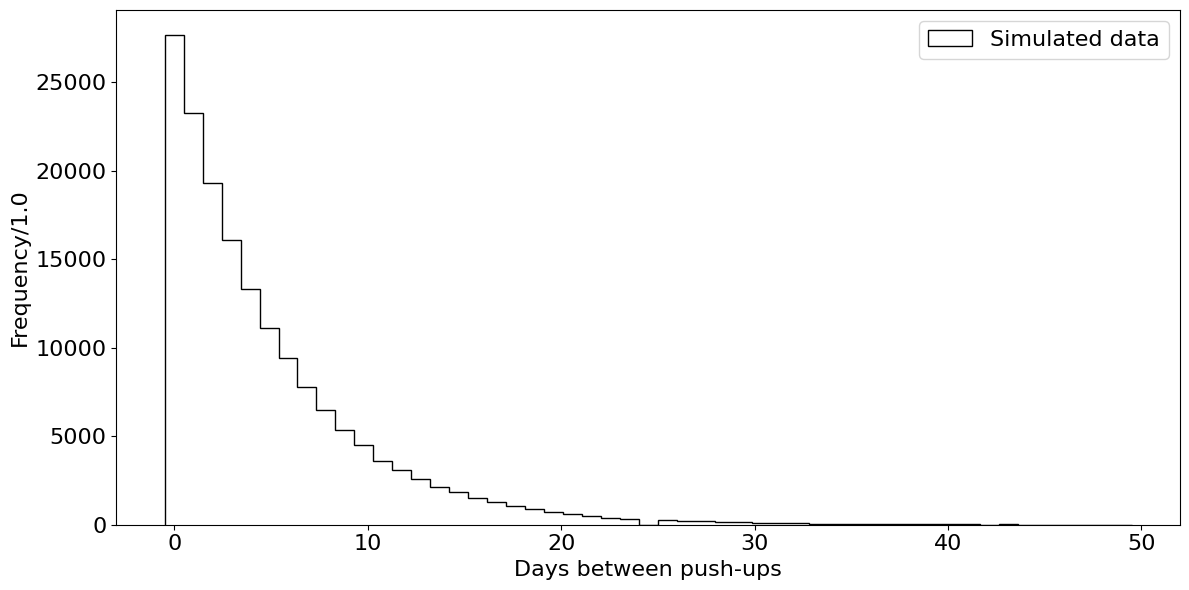

In [248]:
fig, ax = plt.subplots(figsize = (12,6))
min_days, max_days = np.min(days_between_pups), 50

no_bins_days = max_days - min_days + 1
bin_width_days = (max_days - min_days) / no_bins_days

ax.hist(days_between_pups, bins=no_bins_days, range = (min_days-0.5, max_days-0.5), histtype = 'step', color='k', label = 'Simulated data')
ax.set_xlabel('Days between push-ups', fontsize = 16)
ax.set_ylabel(f'Frequency/{bin_width_days:.1f}', fontsize = 16)
ax.legend(loc = 'upper right', fontsize = 16)
ax.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()
plt.show()

Geometric distribution - see wiki

### For 10 days:

In [249]:
no_pups_10days = np.sum(np.split(push_up_sim, N_pups_exp/10), axis = 1)

print(no_pups_10days)

pups_std_10days = np.std(no_pups_10days)

pups_mean_10days = np.mean(no_pups_10days)
pups_mean_error_10days = pups_std_10days/np.sqrt(N_pups_exp/10)

pups_median_10days = np.median(no_pups_10days)

print(f'Standard deviation of push-ups in 10 days: {pups_std_10days:.2f}')
print(f'Mean number of push-ups in 10 days: {pups_mean_10days:.2f} ± {pups_mean_error_10days:.2f}')
print(f'Median number of push-ups in 10 days: {pups_median_10days}')

[70. 42. 44. ... 79. 78. 37.]
Standard deviation of push-ups in 10 days: 24.23
Mean number of push-ups in 10 days: 33.38 ± 0.08
Median number of push-ups in 10 days: 31.0


## 1.2

In [250]:
djoser_span = 6
djoser_degrees = 90

prob_djoser_ns = djoser_span/djoser_degrees * 100 

print(f'Probability of Djoser randomly being NS-aligned within 3 degrees is: {prob_djoser_ns:.2f}%')

Probability of Djoser randomly being NS-aligned within 3 degrees is: 6.67%


# Problem 2 

## 2.1

In [251]:
from IPython.core.display import Latex

def lprint(*args,**kwargs):
    """Pretty print arguments as LaTeX using IPython display system 
    
    Parameters
    ----------
    args : tuple 
        What to print (in LaTeX math mode)
    kwargs : dict 
        optional keywords to pass to `display` 
    """
    display(Latex('$$'+' '.join(args)+'$$'),**kwargs)

In [252]:
r_cross = 149*1e-6
r_cross_err = 3*1e-6

r_sol = 25*1e-6
r_sol_err = 5*1e-6

r_com = 309*1e-6
r_com_err = 20*1e-6

$r = fr_s + (1-f)r_c$

$ f = (r-r_c) / (r_s - r_c)$

In [253]:
def water_frac(r_cross, r_cross_err, r_sol, r_sol_err, r_com, r_com_err):
    frac, r_e, r_s, r_c, r_e_err, r_s_err, r_c_err = symbols('frac, r_e, r_s, r_c, r_e_err, r_s_err, r_c_err')

    frac = (r_e - r_c) / (r_s - r_c)
    lprint(latex(Eq(symbols('frac'), frac)))
    frac_err = sqrt((frac.diff(r_e)*r_e_err)**2 + (frac.diff(r_s)*r_s_err)**2 + (frac.diff(r_c)*r_c_err)**2)
    lprint(latex(Eq(symbols('sigma_frac'), frac_err)))

    frac_func = lambdify((r_e, r_s, r_c), frac)
    frac_err_func = lambdify((r_e, r_s, r_c, r_e_err, r_s_err, r_c_err), frac_err)

    frac_val = frac_func(r_cross, r_sol, r_com)
    frac_err_val = frac_err_func(r_cross, r_sol, r_com, r_cross_err, r_sol_err, r_com_err)

    return frac_val, frac_err_val

frac, frac_err = water_frac(r_cross, r_cross_err, r_sol, r_sol_err, r_com, r_com_err)

print(f'Fraction from proto: {frac:.2f} ± {frac_err:.2f} and frac from comect = {1 - frac:.2f} ± {frac_err:.2f}')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Fraction from proto: 0.56 ± 0.03 and frac from comect = 0.44 ± 0.03


## 2.2

### 2.2.1

In [254]:
deltaT_detec = 98.4 #s
N_detec = 1971 #counts
deltaT_detec_err = 3.7 #s

print(np.sqrt(N_detec))

def estimated_rate(N_counts, dT_interval, sig_dT_interval):
    r, N, dt, sig_r, sig_N, sig_dt = symbols('r, N, dt, sig_r, sig_N, sig_dt')
    r = N/dt 
    sig_r = sqrt((r.diff(N)*sig_N)**2 + (r.diff(dt)*sig_dt)**2)

    r_func = lambdify((N, dt), r)
    sig_r_func = lambdify((N, dt, sig_N, sig_dt), sig_r)

    r_val = r_func(N_counts, dT_interval)

    N_err_val = np.sqrt(N_counts)

    r_err_val = sig_r_func(N_counts, dT_interval, N_err_val, sig_dT_interval)

    return r_val, r_err_val

detected_rate_val, detected_rate_err = estimated_rate(N_detec, deltaT_detec, deltaT_detec_err)

print(f'Estimated rate: ({detected_rate_val:.1f} ± {detected_rate_err:.1f}) counts/s')

44.395945760846224
Estimated rate: (20.0 ± 0.9) counts/s


### 2.2.2

Q: What should dT be, for the error on count to be 2.5% of rate? 

In [255]:
def rate_timefinder(r_init, dt_init, dt_err, frac_goal):
    hit_goal = False

    def count_func(r_hat, dt):
        return r_hat * dt
    
    r = r_init
    r_err = 0
    dt = dt_init

    while not hit_goal:
        counts = count_func(r, dt)
        r, r_err = estimated_rate(counts, dt, dt_err)

        loop_frac = r_err / r 

        if loop_frac < frac_goal:
            hit_goal = True
        else:
            dt = dt + 0.1
    
    return np.array([r, r_err, dt, count_func(r, dt)])

In [256]:
rel_unc_detec = rate_timefinder(detected_rate_val, deltaT_detec, deltaT_detec_err, 0.025)

In [257]:
print(f'Time needed to reach 2.5% relative error: {rel_unc_detec[2]:.1f} s with relative error {rel_unc_detec[1]/rel_unc_detec[0]*100:.2f}%')

Time needed to reach 2.5% relative error: 193.3 s with relative error 2.50%


## 2.3

Read data:

In [ ]:
def pylon_data_reader(filename):
    data = np.genfromtxt(filename, delimiter=',', skip_header = 1, names=('Pos', 'Err'))
    return data['Pos'], data['Err']

pylon_pos, pylon_err = pylon_data_reader('Data/data_PylonPositions.csv')

### 2.3.1

In [259]:
pos_mask_1 = pylon_pos < 60
pos_mask_2 = (pylon_pos >=60) & (pylon_pos < 120)
pos_mask_3 = (pylon_pos >= 120) & (pylon_pos < 150)
pos_mask_4 = pylon_pos >= 150

print(np.sum(pos_mask_1), np.sum(pos_mask_2), np.sum(pos_mask_3), np.sum(pos_mask_4))

def pylon_pos_no_unc(pylon_data, mask):
    data = pylon_data[mask]
    mean_pos = np.mean(pylon_data[mask])
    mean_pos_err = np.std(pylon_data[mask])/np.sqrt(len(pylon_data[mask]))
    return data, mean_pos, mean_pos_err


pylon_data_1, pylon_pos_1, pylon_pos_1_err = pylon_pos_no_unc(pylon_pos, pos_mask_1)
pylon_data_2, pylon_pos_2, pylon_pos_2_err = pylon_pos_no_unc(pylon_pos, pos_mask_2)
pylon_data_3, pylon_pos_3, pylon_pos_3_err = pylon_pos_no_unc(pylon_pos, pos_mask_3)
pylon_data_4, pylon_pos_4, pylon_pos_4_err = pylon_pos_no_unc(pylon_pos, pos_mask_4)

print(f'Pylon position 1: {pylon_pos_1:.1f} ± {pylon_pos_1_err:.1f}')
print(f'Pylon position 2: {pylon_pos_2:.1f} ± {pylon_pos_2_err:.1f}')
print(f'Pylon position 3: {pylon_pos_3:.1f} ± {pylon_pos_3_err:.1f}')
print(f'Pylon position 4: {pylon_pos_4:.1f} ± {pylon_pos_4_err:.1f}')

29 31 30 30
Pylon position 1: 50.1 ± 0.7
Pylon position 2: 91.1 ± 1.0
Pylon position 3: 132.0 ± 0.4
Pylon position 4: 172.1 ± 0.5


In [260]:
def chauvenet_filter(x):
    mean = np.mean(x)
    std = np.std(x)
    N = len(x)

    z = np.abs((x - mean) / std)  
    P = stats.norm.sf(z) * 2 
    PN = P*N

    mask = PN >= 0.5    

    return mask, z

def chauvenet_data(x):
    accepted = x.copy()
    rejected = np.array([])
    zvals = np.array([])
    while True:
        mask, z = chauvenet_filter(accepted)
        if np.all(mask):
            break
        inv_mask = np.logical_not(mask)
        newly_rejected = accepted[inv_mask]
        z_rej = z[inv_mask]
        rejected = np.concatenate((rejected, newly_rejected))
        zvals = np.concatenate((zvals, z_rej))
        accepted = accepted[mask]
        
    return accepted, rejected, mask, zvals    

In [261]:
pyl1_acc, pyl1_rej, pyl1_mask, pyl1_z = chauvenet_data(pylon_data_1)
pyl2_acc, pyl2_rej, pyl2_mask, pyl2_z = chauvenet_data(pylon_data_2)
pyl3_acc, pyl3_rej, pyl3_mask, pyl3_z = chauvenet_data(pylon_data_3)
pyl4_acc, pyl4_rej, pyl4_mask, pyl4_z = chauvenet_data(pylon_data_4)

accepted_pyl_pos = np.concatenate((pyl1_acc, pyl2_acc, pyl3_acc, pyl4_acc))
rejected_pyl_pos = np.concatenate((pyl1_rej, pyl2_rej, pyl3_rej, pyl4_rej))

In [262]:
N_pyl = len(accepted_pyl_pos)
min_pyl, max_pyl = min(accepted_pyl_pos), max(accepted_pyl_pos)

pyl_count, pyl_bin_edges = np.histogram(accepted_pyl_pos, bins=N_pyl, range=(min_pyl, max_pyl))
x_pyl = (pyl_bin_edges[1:] + pyl_bin_edges[:-1])/2
y_pyl = pyl_count
y_pyl_err = np.sqrt(y_pyl)
pyl_binwidth = pyl_bin_edges[1] - pyl_bin_edges[0]

rej_pyl_count, rej_pyl_binedg = np.histogram(rejected_pyl_pos, bins = len(rejected_pyl_pos), range=(min_pyl, max_pyl))
x_rej_pyl = (rej_pyl_binedg[1:] + rej_pyl_binedg[:-1])/2
y_rej_pyl = rej_pyl_count 
y_rej_pyl_err = np.sqrt(y_rej_pyl)

In [263]:
def gauss_pdf(x, mu, sigma) :
    return 1.0 / np.sqrt(2*np.pi) / sigma * np.exp( -0.5 * (x-mu)**2 / sigma**2)

In [264]:
def fit_pdf_llhfit(x, N, mu, sigma):
    return N, N * gauss_pdf(x, mu, sigma)

In [265]:
def fit_pdf_llhfit_full(x, N, mu1, mu2, mu3, mu4, sigma1, sigma2, sigma3, sigma4):
    return N, N/4*(gauss_pdf(x, mu1, sigma1) + gauss_pdf(x, mu2, sigma2) + gauss_pdf(x, mu3, sigma3) + gauss_pdf(x, mu4, sigma4))

In [ ]:
def UNLL_fit_func(x, Npoints, mu_est, sigma_est):
    ullhfit = cost.ExtendedUnbinnedNLL(x, fit_pdf_llhfit)
    minuit_ullh = Minuit(ullhfit, N=Npoints, mu=mu_est, sigma=sigma_est)
    minuit_ullh.migrad();
    vals = minuit_ullh.values[:]
    errors = minuit_ullh.errors[:]

    x_vals = np.linspace(min(x)-10, max(x)+10, 1000)
    y_vals = fit_pdf_llhfit(x_vals, *vals)[1]
    return vals, errors, x_vals, y_vals

In [267]:
def UNLL_full_fit_func(x, Npoints, mu1_est, mu2_est, mu3_est, mu4_est, sigma1_est, sigma2_est, sigma3_est, sigma4_est):
    ullhfit = cost.ExtendedUnbinnedNLL(x, fit_pdf_llhfit_full)
    minuit_ullh = Minuit(ullhfit, N=Npoints, mu1=mu1_est, mu2=mu2_est, mu3=mu3_est, mu4=mu4_est, sigma1=sigma1_est, sigma2=sigma2_est, sigma3=sigma3_est, sigma4=sigma4_est)
    minuit_ullh.migrad();
    vals = minuit_ullh.values[:]
    errors = minuit_ullh.errors[:]

    x_vals = np.linspace(min(x)-10, max(x)+10, 1000)
    y_vals = fit_pdf_llhfit_full(x_vals, *vals)[1]
    return vals, errors, x_vals, y_vals

In [268]:
UNLL_pyl1, UNLL_pyl1_err, x_pyl1, y_pyl1 = UNLL_fit_func(pyl1_acc, len(pyl1_acc), pylon_pos_1, pylon_pos_1_err)
UNLL_pyl2, UNLL_pyl2_err, x_pyl2, y_pyl2 = UNLL_fit_func(pyl2_acc, len(pyl2_acc), pylon_pos_2, pylon_pos_2_err)
UNLL_pyl3, UNLL_pyl3_err, x_pyl3, y_pyl3 = UNLL_fit_func(pyl3_acc, len(pyl3_acc), pylon_pos_3, pylon_pos_3_err)
UNLL_pyl4, UNLL_pyl4_err, x_pyl4, y_pyl4 = UNLL_fit_func(pyl4_acc, len(pyl4_acc), pylon_pos_4, pylon_pos_4_err)

UNLL_full, UNLL_full_err, x_full, y_full = UNLL_full_fit_func(accepted_pyl_pos, len(accepted_pyl_pos), pylon_pos_1, pylon_pos_2, pylon_pos_3, pylon_pos_4, pylon_pos_1_err, pylon_pos_2_err, pylon_pos_3_err, pylon_pos_4_err)

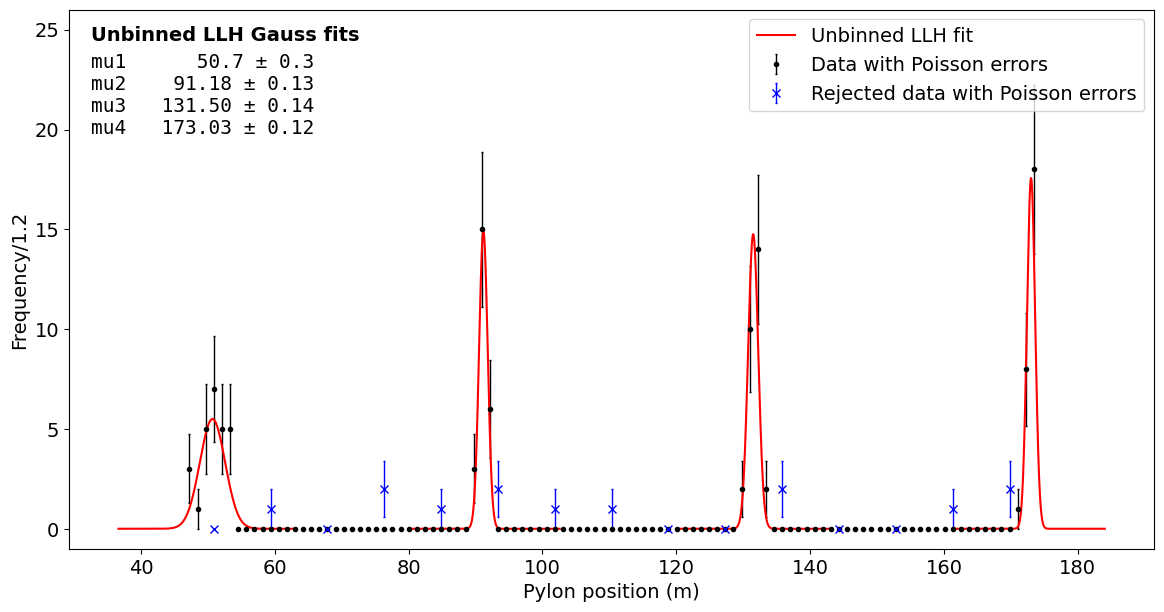

In [269]:
def unbinned_llh_plot():

    fig, ax = plt.subplots(figsize = (14,7))
    ax.errorbar(x_pyl, y_pyl, yerr = y_pyl_err, label='Data with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
    ax.errorbar(x_rej_pyl, y_rej_pyl, yerr = y_rej_pyl_err, label='Rejected data with Poisson errors', fmt='x', color = 'b', ecolor='b', elinewidth=1, capsize=1, capthick=1)
    ax.plot(x_pyl1, y_pyl1, '-', color = 'red', label='Unbinned LLH fit')
    ax.plot(x_pyl2, y_pyl2, '-', color = 'red')
    ax.plot(x_pyl3, y_pyl3, '-', color = 'red')
    ax.plot(x_pyl4, y_pyl4, '-', color = 'red')
    #ax.plot(x_full, y_full, '--', color = 'green', label='Full Unbinned LLH fit')
    ax.set_xlabel('Pylon position (m)', fontsize = 14)
    ax.set_ylabel(f'Frequency/{pyl_binwidth:.1f}', fontsize = 14)
    ax.legend(loc = 'upper right', fontsize = 14)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_ylim(-1, max(y_pyl)+8)


    d = {
    'mu1': f"{UNLL_pyl1[1]:.1f} ± {UNLL_pyl1_err[1]:.1f}",
    'mu2': f"{UNLL_pyl2[1]:.2f} ± {UNLL_pyl2_err[1]:.2f}",
    'mu3': f"{UNLL_pyl3[1]:.2f} ± {UNLL_pyl3_err[1]:.2f}",
    'mu4': f"{UNLL_pyl4[1]:.2f} ± {UNLL_pyl4_err[1]:.2f}",
    }

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 14, color = 'black')
    ax.text(0.02, 0.97, 'Unbinned LLH Gauss fits', weight = 'heavy', fontsize = 14, transform = ax.transAxes, verticalalignment = 'top', color = 'black')

    
    plt.show()
    

    return 

unbinned_llh_plot()

In [270]:
def weighted_mean(xs, sigs):
    num = np.sum(xs/(sigs**2))
    denom = np.sum(1/(sigs**2))
    w_x = num / denom
    w_sig = np.sqrt(1/denom)

    chi2 = np.sum((xs-w_x)**2/(sigs**2))
    Ndof = len(xs)-1
    prob = stats.chi2.sf(chi2, Ndof)
    
    return w_x, w_sig, chi2, prob, Ndof

def z_test_means(mu1, sig1, mu2, sig2):
    z = (mu1 - mu2) / np.sqrt(sig1**2 + sig2**2)
    p = 2 * (1 - norm.cdf(abs(z)))  # two-sided p-value
    return z, p

In [271]:
pylon_1 = np.array([pylon_pos_1, UNLL_pyl1[1]])
pylon_2 = np.array([pylon_pos_2, UNLL_pyl2[1]])
pylon_3 = np.array([pylon_pos_3, UNLL_pyl3[1]])
pylon_4 = np.array([pylon_pos_4, UNLL_pyl4[1]])

pylon_1_err = np.array([pylon_pos_1_err, UNLL_pyl1_err[1]])
pylon_2_err = np.array([pylon_pos_2_err, UNLL_pyl2_err[1]])
pylon_3_err = np.array([pylon_pos_3_err, UNLL_pyl3_err[1]])
pylon_4_err = np.array([pylon_pos_4_err, UNLL_pyl4_err[1]])

w_pyl_1, w_pyl_1_err, chi2_pyl1, prob_pyl1, Ndof_pyl1 = weighted_mean(pylon_1, pylon_1_err)
w_pyl_2, w_pyl_2_err, chi2_pyl2, prob_pyl2, Ndof_pyl2 = weighted_mean(pylon_2, pylon_2_err)
w_pyl_3, w_pyl_3_err, chi2_pyl3, prob_pyl3, Ndof_pyl3 = weighted_mean(pylon_3, pylon_3_err)
w_pyl_4, w_pyl_4_err, chi2_pyl4, prob_pyl4, Ndof_pyl4 = weighted_mean(pylon_4, pylon_4_err)

print(f'Weighted mean pylon 1: {w_pyl_1:.2f} ± {w_pyl_1_err:.2f}, chi2 = {chi2_pyl1:.2f}, prob = {prob_pyl1:.2f}, Ndof = {Ndof_pyl1}')
print(f'Weighted mean pylon 2: {w_pyl_2:.2f} ± {w_pyl_2_err:.2f}, chi2 = {chi2_pyl2:.5f}, prob = {prob_pyl2:.6f}, Ndof = {Ndof_pyl2}')
print(f'Weighted mean pylon 3: {w_pyl_3:.2f} ± {w_pyl_3_err:.2f}, chi2 = {chi2_pyl3:.2f}, prob = {prob_pyl3:.2f}, Ndof = {Ndof_pyl3}')
print(f'Weighted mean pylon 4: {w_pyl_4:.2f} ± {w_pyl_4_err:.2f}, chi2 = {chi2_pyl4:.2f}, prob = {prob_pyl4:.2f}, Ndof = {Ndof_pyl4}')


z1_nonuc, p1_nonuc = z_test_means(UNLL_pyl1[1], UNLL_pyl1_err[1], pylon_pos_1, pylon_pos_1_err)
z2_nonuc, p2_nonuc = z_test_means(UNLL_pyl2[1], UNLL_pyl2_err[1], pylon_pos_2, pylon_pos_2_err)
z3_nonuc, p3_nonuc = z_test_means(UNLL_pyl3[1], UNLL_pyl3_err[1], pylon_pos_3, pylon_pos_3_err)
z4_nonuc, p4_nonuc = z_test_means(UNLL_pyl4[1], UNLL_pyl4_err[1], pylon_pos_4, pylon_pos_4_err)

print(f'Pylon 1 z-test (no unc vs with unc): z = {z1_nonuc:.2f}, p = {p1_nonuc:.4f}')
print(f'Pylon 2 z-test (no unc vs with unc): z = {z2_nonuc:.2f}, p = {p2_nonuc:.4f}')
print(f'Pylon 3 z-test (no unc vs with unc): z = {z3_nonuc:.2f}, p = {p3_nonuc:.4f}')
print(f'Pylon 4 z-test (no unc vs with unc): z = {z4_nonuc:.2f}, p = {p4_nonuc:.4f}')

Weighted mean pylon 1: 50.58 ± 0.30, chi2 = 0.56, prob = 0.45, Ndof = 1
Weighted mean pylon 2: 91.18 ± 0.13, chi2 = 0.00080, prob = 0.977439, Ndof = 1
Weighted mean pylon 3: 131.57 ± 0.13, chi2 = 1.55, prob = 0.21, Ndof = 1
Weighted mean pylon 4: 172.99 ± 0.12, chi2 = 2.73, prob = 0.10, Ndof = 1
Pylon 1 z-test (no unc vs with unc): z = 0.75, p = 0.4543
Pylon 2 z-test (no unc vs with unc): z = 0.03, p = 0.9774
Pylon 3 z-test (no unc vs with unc): z = -1.25, p = 0.2125
Pylon 4 z-test (no unc vs with unc): z = 1.65, p = 0.0985


### 2.3.2

In [272]:
def uncertainty_filter(x, x_err):
    mask = x_err>= 0
    x_filtered = x[mask]
    x_err_filtered = x_err[mask]
    return x_filtered, x_err_filtered

pylon_filtered, pylon_err_filtered = uncertainty_filter(pylon_pos, pylon_err)

def pull_pylon_filter(x, x_err):
    mask_1 = x < 60
    mask_2 = (x >=60) & (x < 120)
    mask_3 = (x >= 120) & (x < 150)
    mask_4 = x >= 150

    x1, x1_err = x[mask_1], x_err[mask_1]
    x2, x2_err = x[mask_2], x_err[mask_2]
    x3, x3_err = x[mask_3], x_err[mask_3]
    x4, x4_err = x[mask_4], x_err[mask_4]

    mu1 = np.mean(x1)
    z1 = (x1 - mu1) / x1_err
    pull_mask1 = np.abs(z1) < 2
    x1, x1_err = x1[pull_mask1], x1_err[pull_mask1]

    mu2 = np.mean(x2)
    z2 = (x2 - mu2) / x2_err
    pull_mask2 = np.abs(z2) < 2
    x2, x2_err = x2[pull_mask2], x2_err[pull_mask2]

    mu3 = np.mean(x3)
    z3 = (x3 - mu3) / x3_err
    pull_mask3 = np.abs(z3) < 2
    x3, x3_err = x3[pull_mask3], x3_err[pull_mask3]

    mu4 = np.mean(x4)
    z4 = (x4 - mu4) / x4_err
    pull_mask4 = np.abs(z4) < 2
    x4, x4_err = x4[pull_mask4], x4_err[pull_mask4]

    return (x1, x1_err), (x2, x2_err), (x3, x3_err), (x4, x4_err)

pyl1_filt, pyl2_filt, pyl3_filt, pyl4_filt = pull_pylon_filter(pylon_filtered, pylon_err_filtered)

In [273]:
w_pyl1_unc, w_pyl1_unc_err, chi2_pyl1_unc, prob_pyl1_unc, Ndof_pyl1_unc = weighted_mean(pyl1_filt[0], pyl1_filt[1])
w_pyl2_unc, w_pyl2_unc_err, chi2_pyl2_unc, prob_pyl2_unc, Ndof_pyl2_unc = weighted_mean(pyl2_filt[0], pyl2_filt[1])
w_pyl3_unc, w_pyl3_unc_err, chi2_pyl3_unc, prob_pyl3_unc, Ndof_pyl3_unc = weighted_mean(pyl3_filt[0], pyl3_filt[1])
w_pyl4_unc, w_pyl4_unc_err, chi2_pyl4_unc, prob_pyl4_unc, Ndof_pyl4_unc = weighted_mean(pyl4_filt[0], pyl4_filt[1])

print(f'Weighted mean pylon 1 (uncertainty filtered): {w_pyl1_unc:.2f} ± {w_pyl1_unc_err:.2f}, chi2 = {chi2_pyl1_unc:.2f}, prob = {prob_pyl1_unc:.2f}, Ndof = {Ndof_pyl1_unc}')
print(f'Weighted mean pylon 2 (uncertainty filtered): {w_pyl2_unc:.2f} ± {w_pyl2_unc_err:.2f}, chi2 = {chi2_pyl2_unc:.2f}, prob = {prob_pyl2_unc:.2f}, Ndof = {Ndof_pyl2_unc}')
print(f'Weighted mean pylon 3 (uncertainty filtered): {w_pyl3_unc:.2f} ± {w_pyl3_unc_err:.2f}, chi2 = {chi2_pyl3_unc:.2f}, prob = {prob_pyl3_unc:.2f}, Ndof = {Ndof_pyl3_unc}')
print(f'Weighted mean pylon 4 (uncertainty filtered): {w_pyl4_unc:.2f} ± {w_pyl4_unc_err:.2f}, chi2 = {chi2_pyl4_unc:.2f}, prob = {prob_pyl4_unc:.2f}, Ndof = {Ndof_pyl4_unc}')

Weighted mean pylon 1 (uncertainty filtered): 50.57 ± 0.62, chi2 = 8.71, prob = 0.37, Ndof = 8
Weighted mean pylon 2 (uncertainty filtered): 91.00 ± 0.39, chi2 = 3.91, prob = 0.42, Ndof = 4
Weighted mean pylon 3 (uncertainty filtered): 132.08 ± 0.30, chi2 = 4.50, prob = 0.48, Ndof = 5
Weighted mean pylon 4 (uncertainty filtered): 172.73 ± 0.35, chi2 = 1.60, prob = 0.90, Ndof = 5


In [274]:
final_pyl1, final_pyl1_err, chi2_final_pyl1, prob_final_pyl1, Ndof_final_pyl1 = weighted_mean(np.array([w_pyl_1, w_pyl1_unc]), np.array([w_pyl_1_err, w_pyl1_unc_err]))
final_pyl2, final_pyl2_err, chi2_final_pyl2, prob_final_pyl2, Ndof_final_pyl2 = weighted_mean(np.array([w_pyl_2, w_pyl2_unc]), np.array([w_pyl_2_err, w_pyl2_unc_err]))
final_pyl3, final_pyl3_err, chi2_final_pyl3, prob_final_pyl3, Ndof_final_pyl3 = weighted_mean(np.array([w_pyl_3, w_pyl3_unc]), np.array([w_pyl_3_err, w_pyl3_unc_err]))
final_pyl4, final_pyl4_err, chi2_final_pyl4, prob_final_pyl4, Ndof_final_pyl4 = weighted_mean(np.array([w_pyl_4, w_pyl4_unc]), np.array([w_pyl_4_err, w_pyl4_unc_err]))

z1_final, p1_final = z_test_means(w_pyl_1, w_pyl_1_err, w_pyl1_unc, w_pyl1_unc_err)
z2_final, p2_final = z_test_means(w_pyl_2, w_pyl_2_err, w_pyl2_unc, w_pyl2_unc_err)
z3_final, p3_final = z_test_means(w_pyl_3, w_pyl_3_err, w_pyl3_unc, w_pyl3_unc_err)
z4_final, p4_final = z_test_means(w_pyl_4, w_pyl_4_err, w_pyl4_unc, w_pyl4_unc_err)

print(f'Final weighted mean pylon 1: {final_pyl1:.1f} ± {final_pyl1_err:.1f}, chi2 = {chi2_final_pyl1:.5f}, prob = {prob_final_pyl1:.2f}, Ndof = {Ndof_final_pyl1}')
print(f'Final weighted mean pylon 2: {final_pyl2:.2f} ± {final_pyl2_err:.2f}, chi2 = {chi2_final_pyl2:.2f}, prob = {prob_final_pyl2:.2f}, Ndof = {Ndof_final_pyl2}')
print(f'Final weighted mean pylon 3: {final_pyl3:.2f} ± {final_pyl3_err:.2f}, chi2 = {chi2_final_pyl3:.2f}, prob = {prob_final_pyl3:.2f}, Ndof = {Ndof_final_pyl3}')
print(f'Final weighted mean pylon 4: {final_pyl4:.2f} ± {final_pyl4_err:.2f}, chi2 = {chi2_final_pyl4:.2f}, prob = {prob_final_pyl4:.2f}, Ndof = {Ndof_final_pyl4}')

print(f'Final pylon 1 z-test: z = {z1_final:.2f}, p = {p1_final:.4f}')
print(f'Final pylon 2 z-test: z = {z2_final:.2f}, p = {p2_final:.4f}')
print(f'Final pylon 3 z-test: z = {z3_final:.2f}, p = {p3_final:.4f}')
print(f'Final pylon 4 z-test: z = {z4_final:.2f}, p = {p4_final:.4f}')

Final weighted mean pylon 1: 50.6 ± 0.3, chi2 = 0.00014, prob = 0.99, Ndof = 1
Final weighted mean pylon 2: 91.16 ± 0.12, chi2 = 0.19, prob = 0.66, Ndof = 1
Final weighted mean pylon 3: 131.65 ± 0.12, chi2 = 2.41, prob = 0.12, Ndof = 1
Final weighted mean pylon 4: 172.96 ± 0.11, chi2 = 0.50, prob = 0.48, Ndof = 1
Final pylon 1 z-test: z = 0.01, p = 0.9907
Final pylon 2 z-test: z = 0.44, p = 0.6601
Final pylon 3 z-test: z = -1.55, p = 0.1205
Final pylon 4 z-test: z = 0.70, p = 0.4811


In [275]:
pyl12, pyl12_err = final_pyl2 - final_pyl1, np.sqrt(final_pyl1_err**2 + final_pyl2_err**2)
pyl23, pyl23_err = final_pyl3 - final_pyl2, np.sqrt(final_pyl2_err**2 + final_pyl3_err**2)
pyl34, pyl34_err = final_pyl4 - final_pyl3, np.sqrt(final_pyl3_err**2 + final_pyl4_err**2)

print(f'Pylon 1-2 distance (using final weigthed mean): {pyl12:.1f} ± {pyl12_err:.1f} m')
print(f'Pylon 2-3 distance (using final weigthed mean): {pyl23:.1f} ± {pyl23_err:.1f} m')
print(f'Pylon 3-4 distance (using final weigthed mean): {pyl34:.1f} ± {pyl34_err:.1f} m')

Pylon 1-2 distance (using final weigthed mean): 40.6 ± 0.3 m
Pylon 2-3 distance (using final weigthed mean): 40.5 ± 0.2 m
Pylon 3-4 distance (using final weigthed mean): 41.3 ± 0.2 m


# Problem 3

## 3.1

### 3.1.1

In [276]:
A_2d_cent, A_2d_rad = np.array([0,0]), 6
B_2d_cent, B_2d_rad = np.array([3,7]), 4

In [ ]:
r = np.random
r.seed(1)

In [278]:
def circ_box(cent, rad):
    box_min, box_max = cent - rad, cent + rad
    return box_min, box_max

def is_in_circ(points, center, r):
    pos = points - center
    norm = np.linalg.norm(pos, axis=1)
    return norm**2 <= r**2


print(circ_box(B_2d_cent, B_2d_rad))

(array([-1,  3]), array([ 7, 11]))


In [279]:
def MC_AB_circ(centA, radA, centB, radB, N_points):
    dim = len(centA)

    boxA = circ_box(centA, radA)
    boxB = circ_box(centB, radB)

    Avals = r.uniform(boxA[0], boxA[1], size=(N_points, dim))
    Bvals = r.uniform(boxB[0], boxB[1], size=(N_points, dim))

    Amask = is_in_circ(Avals, centA, radA)
    Bmask = is_in_circ(Bvals, centB, radB)

    A_vals_in_circ = Avals[Amask]
    B_vals_in_circ = Bvals[Bmask]

    AB_overlap = is_in_circ(A_vals_in_circ, centB, radB)
    AB_frac = np.sum(AB_overlap) / len(A_vals_in_circ)

    BA_overlap = is_in_circ(B_vals_in_circ, centA, radA)
    BA_frac = np.sum(BA_overlap) / len(B_vals_in_circ)

    frac_vals = np.array([AB_frac, BA_frac])

    overlap_vals = A_vals_in_circ[AB_overlap]

    return A_vals_in_circ, B_vals_in_circ, frac_vals, overlap_vals

In [280]:
A_2d, B_2d, A_B_2d_frac, AB_2d_overlap = MC_AB_circ(A_2d_cent, A_2d_rad, B_2d_cent, B_2d_rad, 1000000)

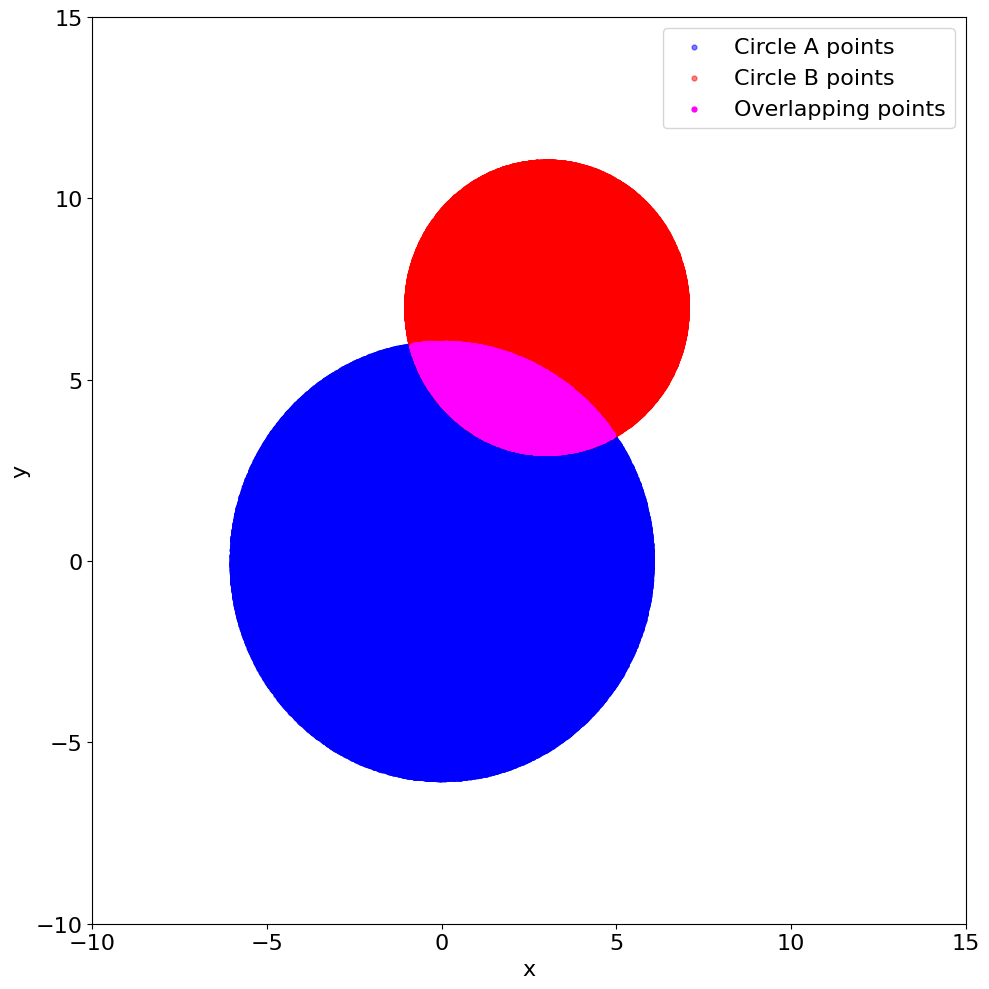

In [281]:
def MC_circ_plot(A, B, olap):
    Ax, Ay = A[:,0], A[:,1]
    Bx, By = B[:,0], B[:,1] 
    Ox, Oy = olap[:,0], olap[:,1]

    fig, ax = plt.subplots(figsize = (10,10))

    ax.scatter(Ax, Ay, marker = 'o', color='blue', alpha = 0.5, label='Circle A points', s = 12)
    ax.scatter(Bx, By, marker = 'o', color='red', alpha = 0.5, label='Circle B points', s = 12)
    ax.scatter(Ox, Oy, marker = 'o', color='magenta', label='Overlapping points', s = 12)

    ax.set_xlim(-10, 15)
    ax.set_ylim(-10, 15)
    ax.set_xlabel('x', fontsize = 16)
    ax.set_ylabel('y', fontsize = 16)
    ax.legend(loc = 'upper right', fontsize = 16)
    ax.tick_params(labelsize=16)
    plt.tight_layout()
    plt.show()

MC_circ_plot(A_2d, B_2d, AB_2d_overlap)

In [282]:
AB_2d_frac, BA_2d_frac = A_B_2d_frac

print(f'Fraction of A inside B: {AB_2d_frac:.3f} in the 2d case')
print(f'Fraction of B inside A: {BA_2d_frac:.3f} in the 2d case')

Fraction of A inside B: 0.091 in the 2d case
Fraction of B inside A: 0.204 in the 2d case


### 3.1.2

In [283]:
A_4d_cent, A_4d_rad = np.array([0,0,0,0]), 6
B_4d_cent, B_4d_rad = np.array([3,7,-1,2]), 4

In [284]:
A_4d, B_4d, A_B_4d_frac, AB_4d_overlap = MC_AB_circ(A_4d_cent, A_4d_rad, B_4d_cent, B_4d_rad, 1000000)

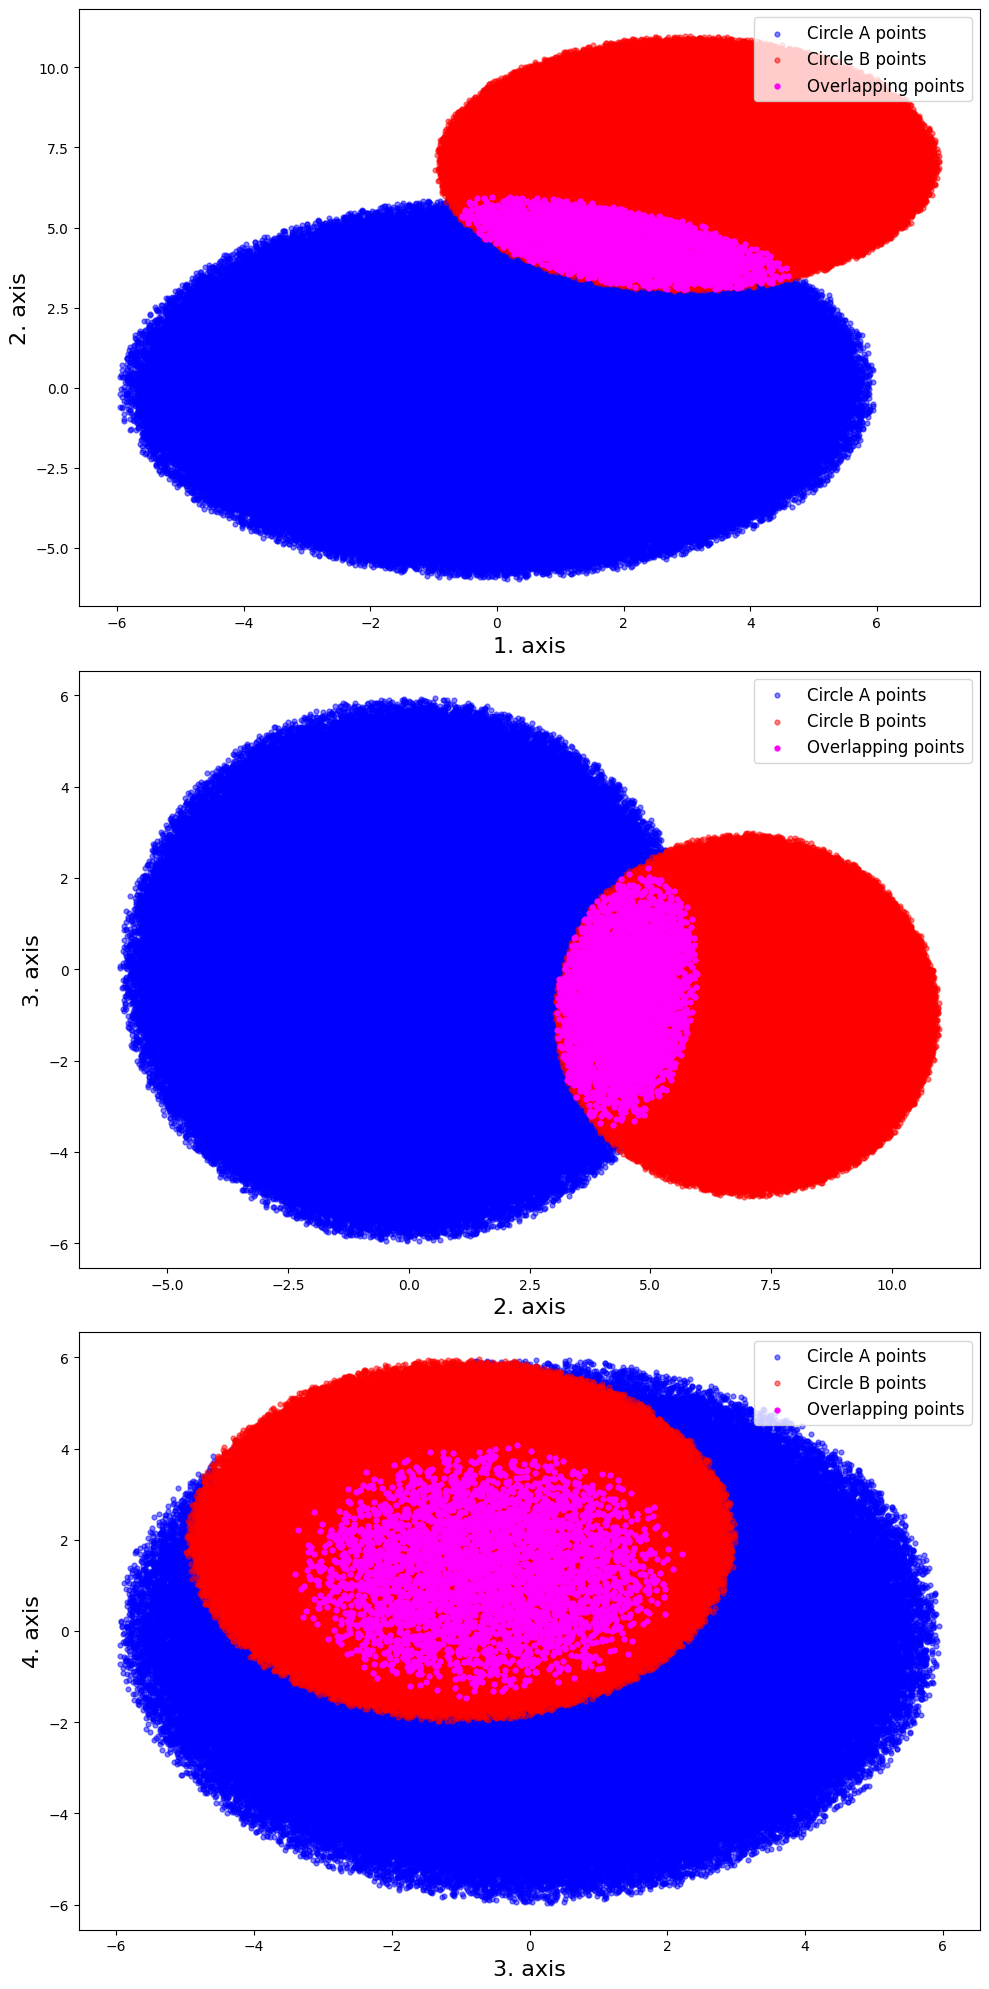

In [285]:
def MC_circ_4d_plot(A, B, olap):
    A_x, A_y, A_z, A_w = A[:,0], A[:,1], A[:,2], A[:,3]
    B_x, B_y, B_z, B_w = B[:,0], B[:,1], B[:,2], B[:,3]
    O_x, O_y, O_z, O_w = olap[:,0], olap[:,1], olap[:,2], olap[:,3]

    fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (10, 20))

    axes[0].scatter(A_x, A_y, marker = 'o', color='blue', alpha = 0.5, label='Circle A points', s = 12)
    axes[0].scatter(B_x, B_y, marker = 'o', color='red', alpha = 0.5, label='Circle B points', s = 12)
    axes[0].scatter(O_x, O_y, marker = 'o', color='magenta', label='Overlapping points', s = 12)
    axes[0].set_xlabel('1. axis', fontsize = 16)
    axes[0].set_ylabel('2. axis', fontsize = 16)
    axes[0].legend(loc = 'upper right', fontsize = 12)

    axes[1].scatter(A_y, A_z, marker = 'o', color='blue', alpha = 0.5, label='Circle A points', s = 12)
    axes[1].scatter(B_y, B_z, marker = 'o', color='red', alpha = 0.5, label='Circle B points', s = 12)
    axes[1].scatter(O_y, O_z, marker = 'o', color='magenta', label='Overlapping points', s = 12)
    axes[1].set_xlabel('2. axis', fontsize = 16)
    axes[1].set_ylabel('3. axis', fontsize = 16)
    axes[1].legend(loc = 'upper right', fontsize = 12)

    axes[2].scatter(A_z, A_w, marker = 'o', color='blue', alpha = 0.5, label='Circle A points', s = 12)
    axes[2].scatter(B_z, B_w, marker = 'o', color='red', alpha = 0.5, label='Circle B points', s = 12)
    axes[2].scatter(O_z, O_w, marker = 'o', color='magenta', label='Overlapping points', s = 12)
    axes[2].set_xlabel('3. axis', fontsize = 16)
    axes[2].set_ylabel('4. axis', fontsize = 16)
    axes[2].legend(loc = 'upper right', fontsize = 12)

    plt.tight_layout()
    plt.show()
    return


MC_circ_4d_plot(A_4d, B_4d, AB_4d_overlap)

In [286]:
AB_4d_frac, BA_4d_frac = A_B_4d_frac

print(f'Fraction of A inside B: {AB_4d_frac:.3f} in the 4d case')
print(f'Fraction of B inside A: {BA_4d_frac:.3f} in the 4d case')

Fraction of A inside B: 0.014 in the 4d case
Fraction of B inside A: 0.074 in the 4d case


## 3.2

### 3.2.1

In [287]:
def expl_rad(N_points):
    pos = r.uniform(-1,1, size=(N_points, 3))
    rad = np.linalg.norm(pos, axis=1)
    return rad

In [288]:
expl_rads = expl_rad(50000)

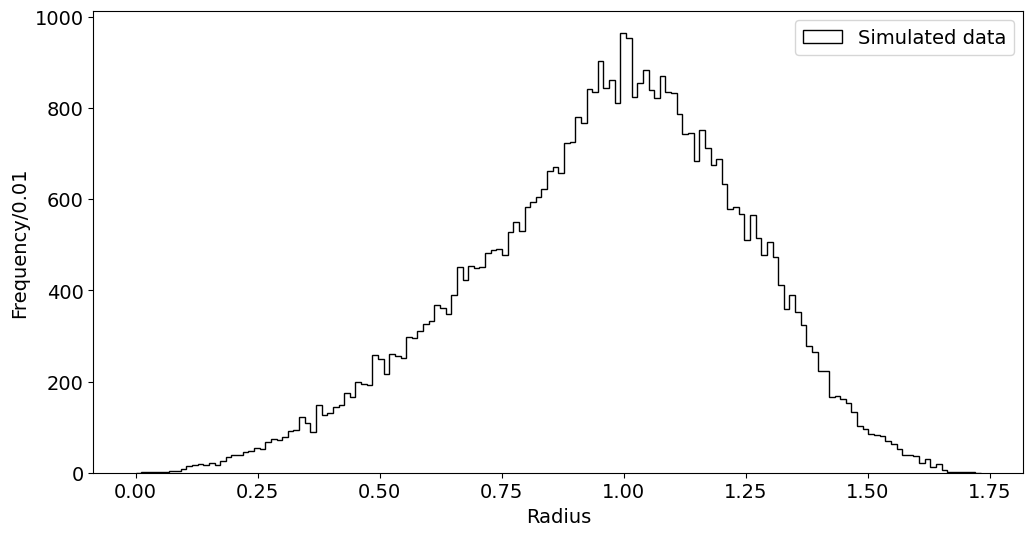

In [ ]:
def expl_rad_hist(rad):
    xmin, xmax = 0, np.sqrt(3)
    bin_number = 150
    bin_width = (xmax - xmin)/bin_number

    fig, ax = plt.subplots(figsize =(12,6))
    ax.hist(rad, bins=bin_number, range = (xmin, xmax), histtype='step', color='k', label='Simulated data')
    ax.set_xlabel('radius', fontsize = 14)
    ax.set_ylabel(f'Frequency/{bin_width:.2f}', fontsize = 14)
    ax.legend(fontsize = 14)
    ax.tick_params(axis = 'both', labelsize = 14)
    plt.show()

    return

expl_rad_hist(expl_rads)

### 3.2.2

In [290]:
def cart_to_spher(pos):
    rad = np.linalg.norm(pos, axis=1)
    theta = np.arccos(pos[:,2] / rad)
    phi = np.arctan2(pos[:,1], pos[:,0])
    return rad, theta, phi

In [291]:
def pos_expl_selecter(N_points, z_min, r_max):
    pos = r.uniform(-1,1, size=(N_points, 3))

    z_mask = pos[:,2] > z_min
    pos = pos[z_mask]

    rad = np.linalg.norm(pos, axis=1)
    rad_mask = rad < r_max
    pos = pos[rad_mask]

    rad, theta, phi = cart_to_spher(pos)

    return theta, phi

In [292]:
expl_theta, expl_phi = pos_expl_selecter(50000, 0, 1)

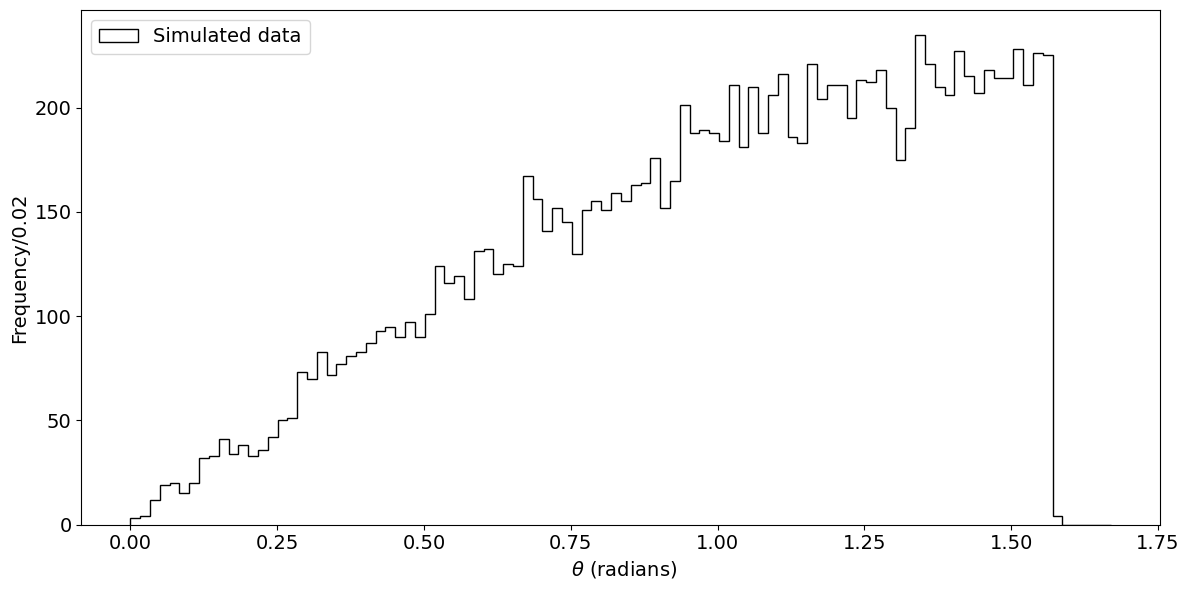

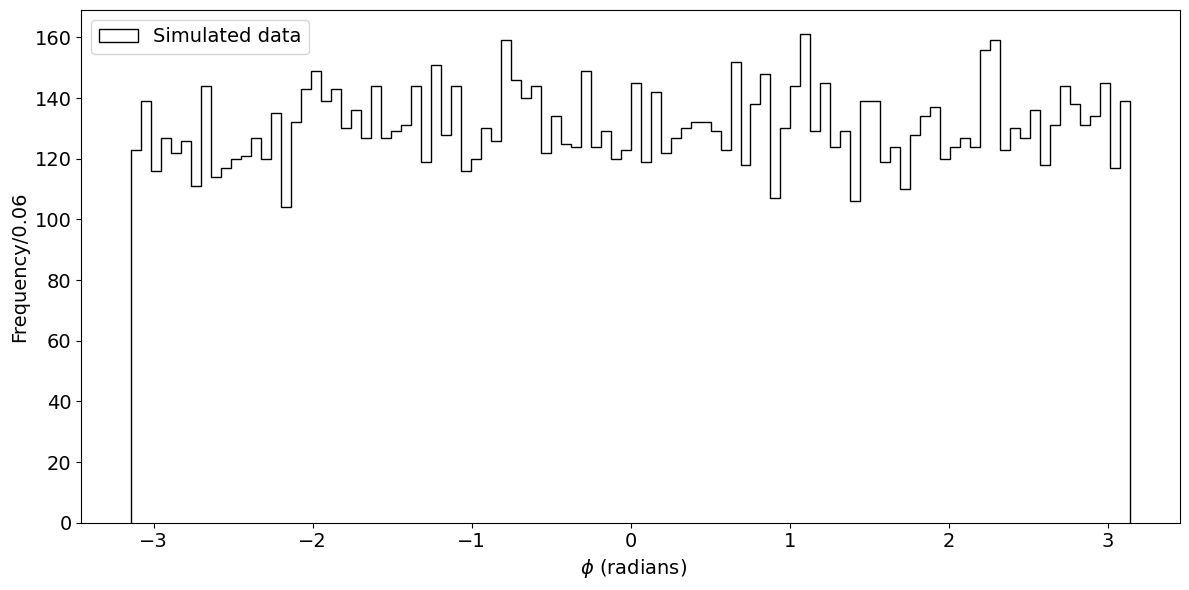

In [293]:
def expl_theta_phi_hist():
    theta_bins = 100
    theta_min, theta_max = 0, np.pi/2 + 0.1
    theta_bin_width = (theta_max - theta_min)/theta_bins

    phi_bins = 100
    phi_min, phi_max = -np.pi, np.pi
    phi_bin_width = (phi_max - phi_min)/phi_bins

    fig, ax1 = plt.subplots(figsize =(12,6))
    ax1.hist(expl_theta, bins=theta_bins, range=(theta_min, theta_max), histtype='step', color='k', label = 'Simulated data')
    ax1.set_xlabel(rf' $\theta$ (radians)', fontsize = 14)
    ax1.set_ylabel(f'Frequency/{theta_bin_width:.2f}', fontsize = 14)
    ax1.legend(fontsize = 14)
    ax1.tick_params(axis = 'both', labelsize = 14)
    plt.tight_layout()
    plt.show()

    fig, ax2 = plt.subplots(figsize =(12,6))
    ax2.hist(expl_phi, bins=phi_bins, range=(phi_min, phi_max), histtype='step', color='k', label = 'Simulated data')
    ax2.set_xlabel(rf' $\phi$ (radians)', fontsize = 14)
    ax2.set_ylabel(f'Frequency/{phi_bin_width:.2f}', fontsize = 14)
    ax2.legend(fontsize = 14)
    ax2.tick_params(axis = 'both', labelsize = 14)
    plt.tight_layout()
    plt.show()


    return

expl_theta_phi_hist()

### 3.2.3

To produce random velocities, $v$, according to $f(v) = (v/v_0)^2 \exp(-v/v_0)$, I would use the Monto-Carlo method. I.e. I would first determined the interval over which this function is valid, here I would assume $v \geq 0$ and $v \leq c$ since it is a velocity. Then I would normalize $f(v)$ by integrating it. Taking $c \approx \infty$ w.r.t. normal velocities, we get: 

$ F(v) = (1/v_0)^2 \int_{0}^{\infty}  dv (v^2) \exp(-v/v_0) = (1/v_0)^2  2v_0^3 = 2v_0$

Thus, normalized: 

$ f(v) = 1/2 \space v^2/v_0^3 \exp(-v/v_0)$

see wiki

### 3.2.4

In [333]:
vel_zero = 100 #m/s

N_theta = len(expl_theta)
print(N_theta)

13098


In [295]:
def veloc_func(v, v_zero):
    return 1/2 * v**2 * (1/(v_zero**3)) * np.exp(-v/v_zero)

In [296]:
def velocs_wrt_f(N_goal, v_zero, f_max, v_max):

    N_points = N_goal*100
    counter = 0

    v_vals = r.uniform(0, v_max, size=N_points)
    y_vals = r.uniform(0, f_max, size=N_points)

    accepted_vals = np.array([])

    for i in range(N_points):
        func_vals = veloc_func(v_vals[i], v_zero)

        if y_vals[i] < func_vals:
            accepted_vals = np.concatenate((accepted_vals, np.array([v_vals[i]])))
            counter += 1
        
        if counter == N_goal:
            break

    return accepted_vals

In [297]:
vel_f = velocs_wrt_f(N_theta, vel_zero, 0.05, 1500)


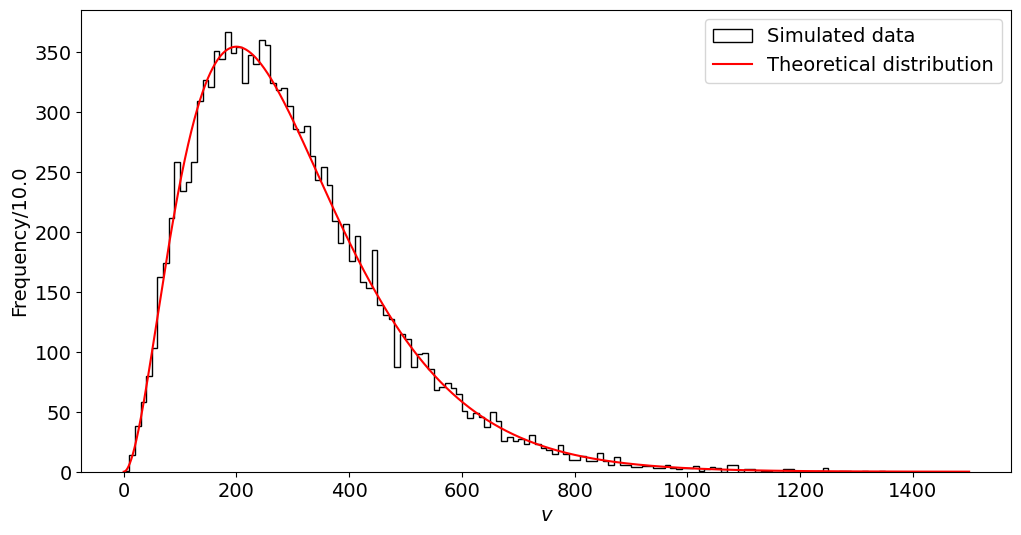

In [336]:
def MC_func_vel_hist(velocs):
    N = len(velocs)
    xmin, xmax = 0, 1500
    bin_number = 150
    bin_width = (xmax - xmin)/bin_number

    v_vals = np.linspace(xmin, xmax, 10000)
    func_vals = veloc_func(v_vals, vel_zero)*N*bin_width

    p_KS = stats.ks_2samp(velocs, func_vals).pvalue

    fig, ax = plt.subplots(figsize =(12,6))
    ax.hist(velocs, bins=bin_number, range = (xmin, xmax), histtype='step', color='k', label='Simulated data')
    ax.plot(v_vals, func_vals, color='red', label='Theoretical distribution')
    ax.set_xlabel('$v$', fontsize = 14)
    ax.set_ylabel(f'Frequency/{bin_width:.1f}', fontsize = 14)
    ax.legend(fontsize = 14)
    ax.tick_params(axis = 'both', labelsize = 14)
    plt.show()

    return

MC_func_vel_hist(vel_f)

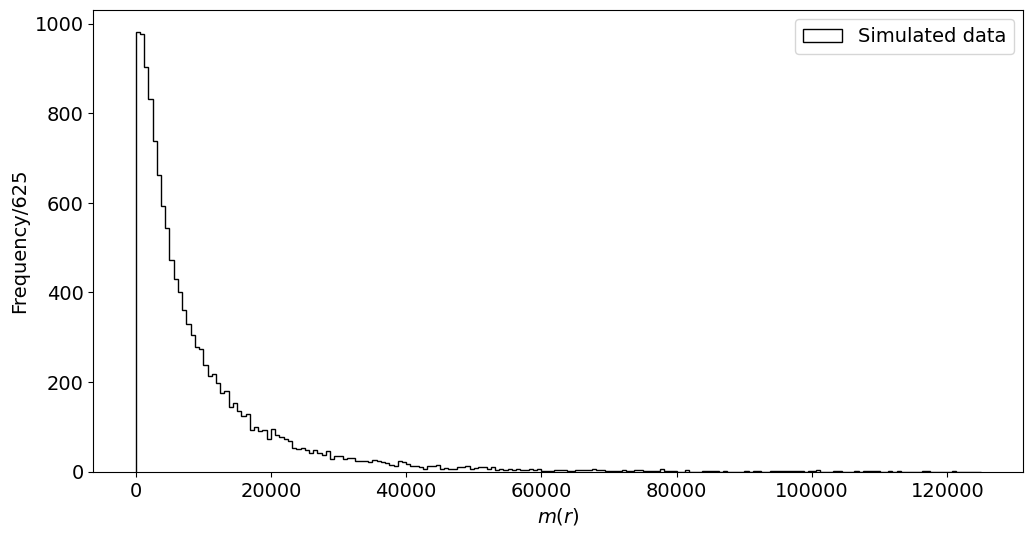

In [340]:
def radial_dist(v, theta):
    return np.sin(theta)*v**2 / 9.82

radial_distances = radial_dist(vel_f, expl_theta)

def radial_dist_hist(radial_distances):
    xmin, xmax = 0, 125000
    bin_number = 200
    bin_width = (xmax - xmin)/bin_number

    fig, ax = plt.subplots(figsize =(12,6))
    ax.hist(radial_distances, bins=bin_number, range = (xmin, xmax), histtype='step', color='k', label='Simulated data')
    ax.set_xlabel('$m(r)$', fontsize = 14)
    ax.set_ylabel(f'Frequency/{bin_width:.0f}', fontsize = 14)
    ax.legend(fontsize = 14)
    ax.tick_params(axis = 'both', labelsize = 14)
    plt.show()

    return

radial_dist_hist(radial_distances)


# Problem 4

## 4.1

### 4.1.1

In [300]:
def order_exchange(data):
    permute = r.permutation(len(data))
    shuffled_data = data[permute]
    return data, shuffled_data


In [301]:
def closed_box(N_rolls, N_dice, fake_die_order):
    n_sets = len(fake_die_order)
    runs = np.zeros((n_sets, N_rolls*N_dice))
    for i in range(n_sets):
        if fake_die_order[i] == False:
            real_die = r.randint(1, 7, size=(N_rolls, N_dice)).flatten()
            runs[i] = real_die
        else: 
            real_die = r.randint(1,7, size=(N_rolls, N_dice-1)).flatten()

            fake_face = r.randint(1,7)
            fake_die = np.ones(N_rolls)*fake_face

            real_die = np.concatenate((real_die, fake_die))

            runs[i] = real_die
    return runs

die_order = [False, True]

In [302]:
closed_box_data = closed_box(200, 25, die_order)
unblinded_box_data, blinded_box_data = order_exchange(closed_box_data)

In [303]:
def pearsons_chi2(observed, expected):
    return np.sum((observed - expected) ** 2 / expected)

def box_chi2(data):
    counts, bin_edg = np.histogram(data, bins=6, range=(0.5,6.5))
    expected = np.ones(len(counts))*(len(data)/6)

    chi2 = pearsons_chi2(counts, expected)
    N_dof = len(counts) - 1

    p = stats.chi2.sf(chi2, N_dof)

    return chi2, N_dof, p, expected


In [304]:
run1, run2 = closed_box_data[0], closed_box_data[1]

[833.33333333 833.33333333 833.33333333 833.33333333 833.33333333
 833.33333333]
Chi2 value: 6.7
Ndof = 5
Prob(Chi2,Ndof) = 0.24490
[833.33333333 833.33333333 833.33333333 833.33333333 833.33333333
 833.33333333]
Chi2 value: 53.8
Ndof = 5
Prob(Chi2,Ndof) = 0.00000


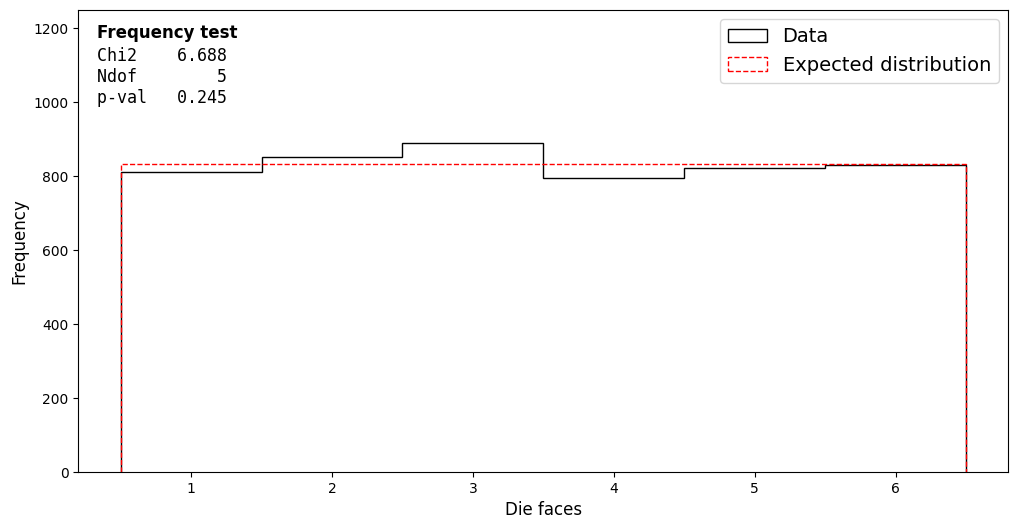

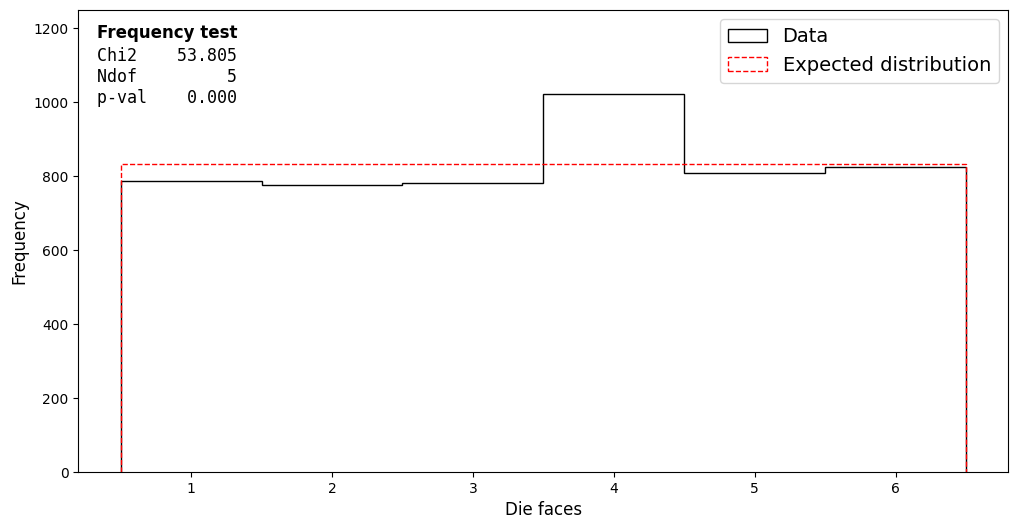

In [305]:
def closed_box_hist(data):
    
    chi2, Ndof, pval, expected = box_chi2(data)
    print(expected)


    fig, ax = plt.subplots(figsize =(12,6))
    ax.hist(data, bins=6, range=(0.5,6.5), histtype='step', color='k', label=f'Data')

    # Creating expected histogram
    ax.hist([1,2,3,4,5,6], bins=6, range=(0.5,6.5), weights=expected, histtype='step', color='red', linestyle='--', label='Expected distribution')

    d = {'Chi2': chi2,
          'Ndof': Ndof,
          'p-val': pval}

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 12, color = 'black')
    ax.text(0.02, 0.97, 'Frequency test', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top', color = 'black')

    ax.legend(fontsize = 14, loc = 'upper right')
    ax.set_xlabel('Die faces', fontsize = 12)
    ax.set_ylabel(f'Frequency', fontsize = 12)
    #Set y limit for better visualization
    ax.set_ylim(0, 1250)
        
    print(f"Chi2 value: {chi2:.1f}")   
    print(f"Ndof = {Ndof:.0f}")
    print(f"Prob(Chi2,Ndof) = {pval:.5f}")

    return 


closed_box_hist(run1)
closed_box_hist(run2)

Let's test if there is a fake die or not. 

## 4.1.3

In [306]:
def runs_before_fake(N_dice, fake_die_order, p_level):
    N_rolls = 1

    hit_crit = False
    while hit_crit == False:
        closed_box_data = closed_box(N_rolls, N_dice, fake_die_order)
        fake_run = closed_box_data[1]

        chi2, dof, p, expc = box_chi2(fake_run)

        if p < p_level:
            hit_crit = True

        else:
            N_rolls += 1
    return N_rolls, chi2, dof, p
    

def mean_Nrolls(N_dice, fake_die_order, N_trials, p_level):
    N_rolls_list = []
    chi2_list = []
    dof_list = []
    p_list = []

    for i in range(N_trials):
        N_rolls, chi2, dof, p = runs_before_fake(N_dice, fake_die_order, p_level)
        N_rolls_list.append(N_rolls)
        chi2_list.append(chi2)
        dof_list.append(dof)
        p_list.append(p)

    mean_N_rolls = np.mean(N_rolls_list)
    mean_N_rolls_err = np.std(N_rolls_list)/np.sqrt(N_trials)
    mean_chi2 = np.mean(chi2_list)
    mean_dof = np.mean(dof_list)
    mean_p = np.mean(p_list)

    return mean_N_rolls, mean_N_rolls_err, mean_chi2, mean_dof, mean_p, N_rolls_list

mean_N_rolls, mean_N_rolls_err, mean_chi2, mean_dof, mean_p, N_rolls_list_fake = mean_Nrolls(25, [True, True], 50000, p_level = 0.01)

C:\Users\asker\AppData\Local\Temp\ipykernel_2292\3314097167.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(Nrolls_vals, diecounts, yerr=Nyerr, fmt='.k', color='k', label='Data with Poisson errors')


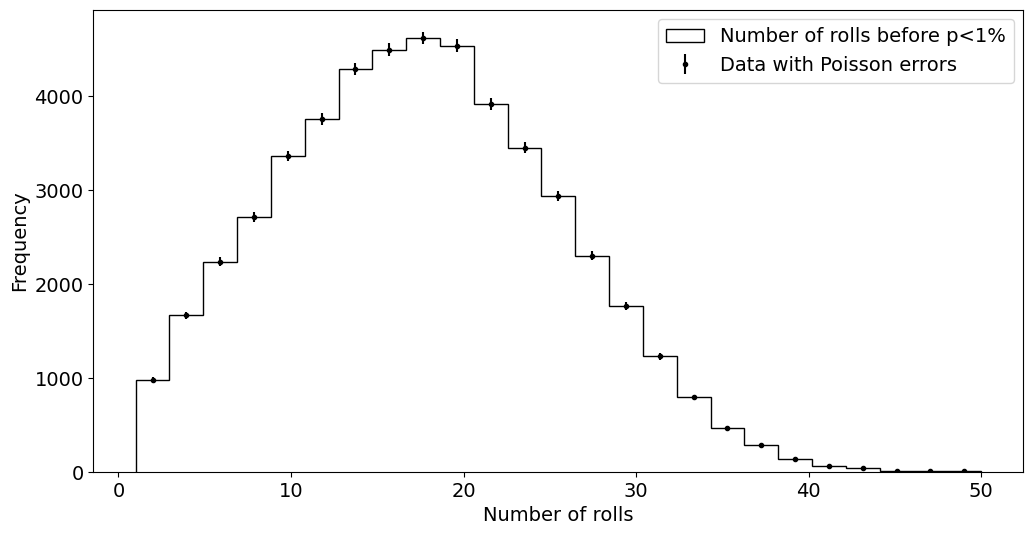

In [349]:
diecounts, diebined = np.histogram(N_rolls_list_fake, bins=25)
Nrolls_vals = 0.5 * (diebined[1:] + diebined[:-1])
Nyerr = np.sqrt(diecounts)

fig, ax = plt.subplots(figsize =(12,6))
ax.hist(N_rolls_list_fake, bins=25, histtype='step', color='k', label=rf'Number of rolls before p<1%')
ax.errorbar(Nrolls_vals, diecounts, yerr=Nyerr, fmt='.k', color='k', label='Data with Poisson errors')
ax.set_xlabel('Number of rolls', fontsize = 14)
ax.set_ylabel('Frequency', fontsize = 14)
ax.legend(fontsize = 14)
ax.tick_params(axis = 'both', labelsize = 14)
plt.show()

[ 1.98  3.94  5.9   7.86  9.82 11.78 13.74 15.7  17.66 19.62 21.58 23.54
 25.5  27.46 29.42 31.38 33.34 35.3  37.26 39.22 41.18 43.14 45.1  47.06
 49.02]
Fit value: N = 51571.25568 +/- 234.19409
Fit value: mu = 16.89719 +/- 0.04482
Fit value: sigma = 8.62960 +/- 0.03260
Chi2 value: 104.6
Ndof = 22
Prob(Chi2,Ndof) = 1.0044178788176302e-12


c:\Users\asker\OneDrive - University of Copenhagen\Desktop\Kandidat\AppStat\Hand in\ExternalFunctions.py:113: FutureWarning: make_func_code is deprecated: Use of ``func_code`` attribute to declare parameters is deprecated. Use ``_parameters`` instead, which is a dict of parameter names to limits.
  self.func_code = make_func_code(describe(self.f)[1:])


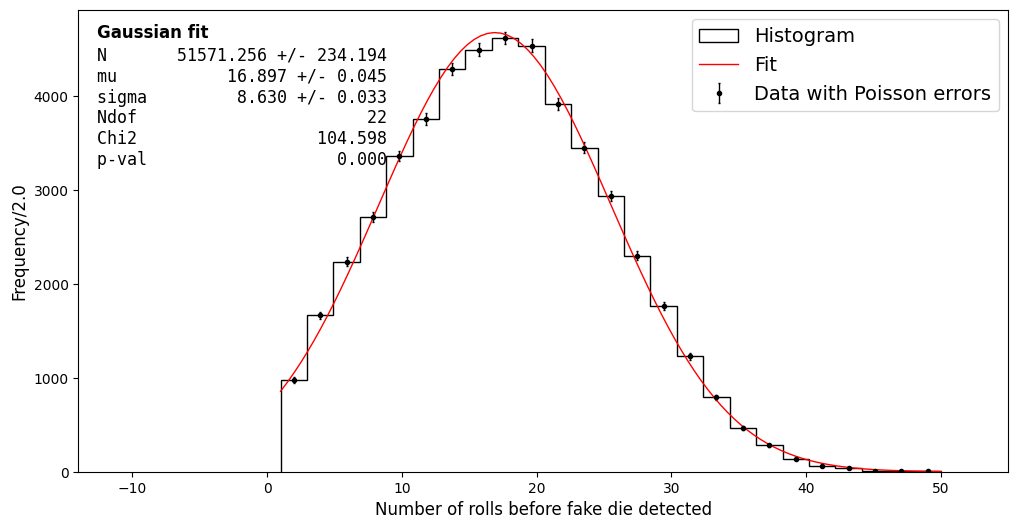

In [350]:
def Nrolls_gauss(data, N_bins,  label = None, ax = None):
    # Create a figure if needed
    if ax is None: fig, ax = plt.subplots(figsize = (12,6))

    # Extract values from histogram and outline data
    counts, bin_edges, _ = ax.hist(data, bins = N_bins, histtype='step', label = 'Histogram', color = 'k')
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    binwidth = bin_edges[1] - bin_edges[0]
    s_counts = np.sqrt(counts) # Poisson errors on the count in each bin
    
    # Removeing any bins without any counts in them:
    x = bin_center[counts > 0]
    print(x)
    y = counts[counts > 0]
    sy = s_counts[counts > 0]

    # Data with errorbars
    ax.errorbar(x, y, yerr = sy, fmt = '.k',  ecolor = 'k', elinewidth = 1, capsize = 1, capthick = 1, label = 'Data with Poisson errors')
    
    # Perform Gaussian fit with exponential background
    def gauss_fit(x, N, mu, sigma):
        return N * binwidth * stats.norm.pdf(x, mu, sigma)

    # Minimizing chi2
    chi2_gauss = Chi2Regression(gauss_fit, x, y, sy)
    minuit_gauss = Minuit(chi2_gauss, N = len(data), mu = np.mean(data), sigma = np.std(data, ddof = 1))  
    minuit_gauss.migrad(); 

    chi2_gauss = minuit_gauss.fval
    Ndof_gauss = len(x) - len(minuit_gauss.values)
    Prob_gauss = stats.chi2.sf(chi2_gauss, Ndof_gauss)
    
    # Extract values from fit
    mean = [minuit_gauss.values['mu'], minuit_gauss.errors['mu']]
    sigma = [minuit_gauss.values['sigma'], minuit_gauss.errors['sigma']]
    N = [minuit_gauss.values['N'], minuit_gauss.errors['N']]

    # Plot
    xaxis = np.linspace(min(data), max(data), 100)
    y_gauss = gauss_fit(xaxis, *minuit_gauss.values)
    ax.plot(xaxis, y_gauss, linewidth = 1, color = 'red', label = 'Fit')
     
    d = {'N': N,
          'mu': mean,
          'sigma': sigma,
          'Ndof': Ndof_gauss,
          'Chi2': chi2_gauss,
          'p-val': Prob_gauss}

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 12, color = 'black')
    ax.text(0.02, 0.97, 'Gaussian fit', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top',  color = 'black')

    ax.legend(fontsize = 14, loc = 'upper right')
    ax.set_xlabel(label, fontsize = 12)
    ax.set_ylabel(f'Frequency/{binwidth:.1f}', fontsize = 12)
    ax.set_xlim(min(data)-15, max(data)+5)
    for name in minuit_gauss.parameters :
        value, error = minuit_gauss.values[name], minuit_gauss.errors[name]
        print(f"Fit value: {name} = {value:.5f} +/- {error:.5f}")
        
    Prob_value = stats.chi2.sf(chi2_gauss, Ndof_gauss) # The chi2 probability given ndof degrees of freedom
    print(f"Chi2 value: {chi2_gauss:.1f}")   
    print(f"Ndof = {Ndof_gauss:.0f}")
    print(f"Prob(Chi2,Ndof) = {Prob_value}")
    
    return 


Nrolls_gauss(N_rolls_list_fake, 25, label = 'Number of rolls before fake die detected')

In [309]:
print(f'Mean number of rolls before fake die detected: {mean_N_rolls:.2f} ± {mean_N_rolls_err:.2f}, Mean Chi2 = {mean_chi2:.2f}, Mean DoF = {mean_dof:.2f}, Mean p-value = {mean_p:.7f}')

Mean number of rolls before fake die detected: 17.39 ± 0.04, Mean Chi2 = 18.68, Mean DoF = 5.00, Mean p-value = 0.0039278


In [310]:
def fake_pval_trace(N_dice, fake_die, max_rolls):
    N_rolls_list = np.arange(1, max_rolls+1, 1, dtype=int)
    p_fakevals = []
    p_realvals = []

    for N_rolls in N_rolls_list:
        closed_box_data = closed_box(N_rolls, N_dice, fake_die)
        real_run = closed_box_data[0]
        fake_run = closed_box_data[1]

        chi2_real, dof_real, p_real, expc_real = box_chi2(real_run)
        chi2_fake, dof_fake, p_fake, expc_fake = box_chi2(fake_run)
    
        p_fakevals.append(p_fake)
        p_realvals.append(p_real)

    return N_rolls_list, p_realvals, p_fakevals

N_rolls_list, p_reals, p_fakes = fake_pval_trace(25, [False, True], 100)

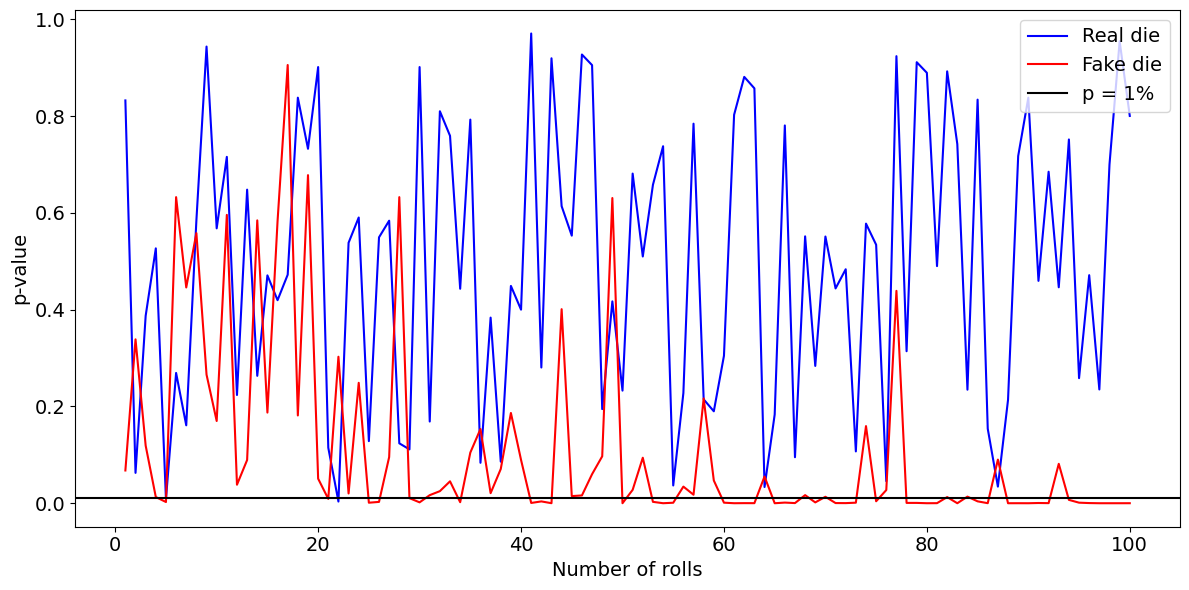

In [351]:
fig, ax = plt.subplots(figsize =(12,6))
ax.plot(N_rolls_list, p_reals, label='Real die', color='blue')
ax.plot(N_rolls_list, p_fakes, label='Fake die', color='red')
ax.axhline(0.01, color='black', label='p = 1%')
ax.set_xlabel('Number of rolls', fontsize = 14)
ax.set_ylabel('p-value', fontsize = 14)
ax.legend(fontsize = 14, loc = 'upper right')
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# Problem V

## 5.1

In [ ]:
dataframe = pd.read_csv('Data/data_InconstantBackground.csv', header=0)
distance = dataframe['# Distance']

C:\Users\asker\AppData\Local\Temp\ipykernel_2292\1999892935.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(bin_cent, y, yerr=sy, fmt='.k', color='k', label='Data with Poisson errors')


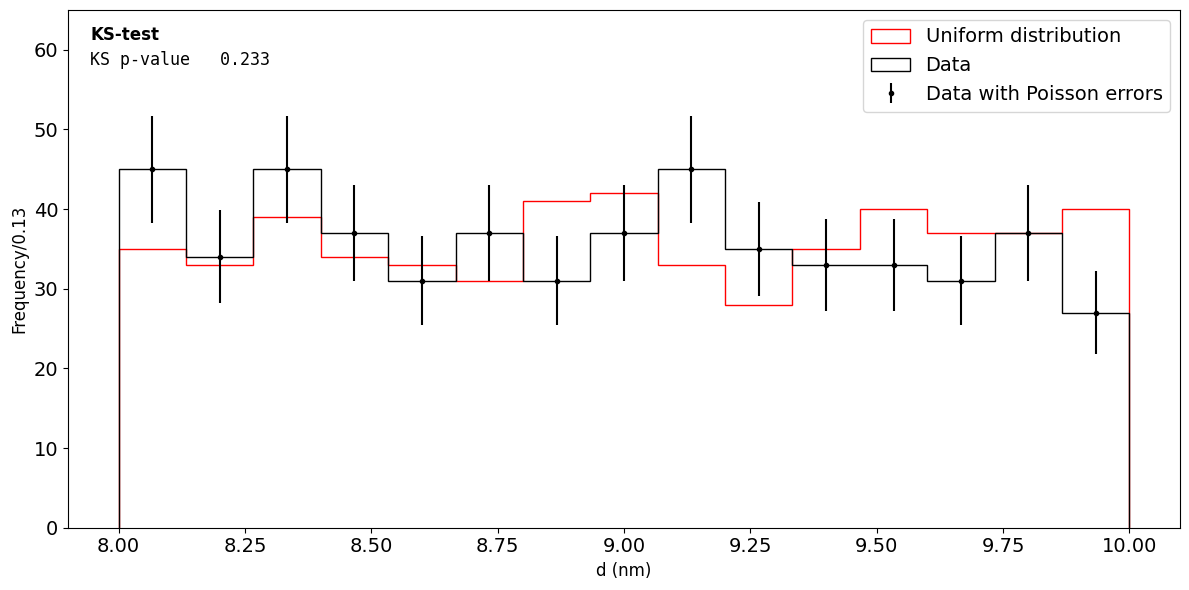

KS test p-value for uniformity between 8m and 10m: 0.2330


In [376]:
unif_mask = (distance >= 8) & (distance<=10)
N_unif_points = len(distance[unif_mask])/2 #pr. m

d_unif = distance[unif_mask]
d_exp = r.uniform(8,10, size=len(d_unif))

p_unif_KS = stats.ks_2samp(d_unif, d_exp)[1]

def KS_unif_test():

    counts, binedg = np.histogram(d_unif, bins=15, range=(8,10))
    bin_cent = 0.5 * (binedg[1:] + binedg[:-1])
    y = counts
    sy = np.sqrt(counts)
    binwidth = binedg[1] - binedg[0]

    d = {'KS p-value': p_unif_KS}

    fig, ax = plt.subplots(figsize =(12,6))
    ax.hist(d_exp, bins=15, range=(8,10), histtype='step', color='red', label='Uniform distribution')
    ax.errorbar(bin_cent, y, yerr=sy, fmt='.k', color='k', label='Data with Poisson errors')
    ax.hist(d_unif, bins=15, range=(8,10), histtype='step', color='k', label='Data')


    ax.tick_params(axis='both', which='major', labelsize=14)

    
    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 12, color = 'black')
    ax.text(0.02, 0.97, 'KS-test', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top',                     color = 'black')

    ax.legend(fontsize = 14, loc = 'upper right')
    ax.set_xlabel('d (nm)', fontsize = 12)
    ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize = 12)
    ax.set_ylim(0, max(y)+20)

    plt.tight_layout()
    plt.show()
    return

KS_unif_test()

print(f'KS test p-value for uniformity between 8m and 10m: {p_unif_KS:.4f}')

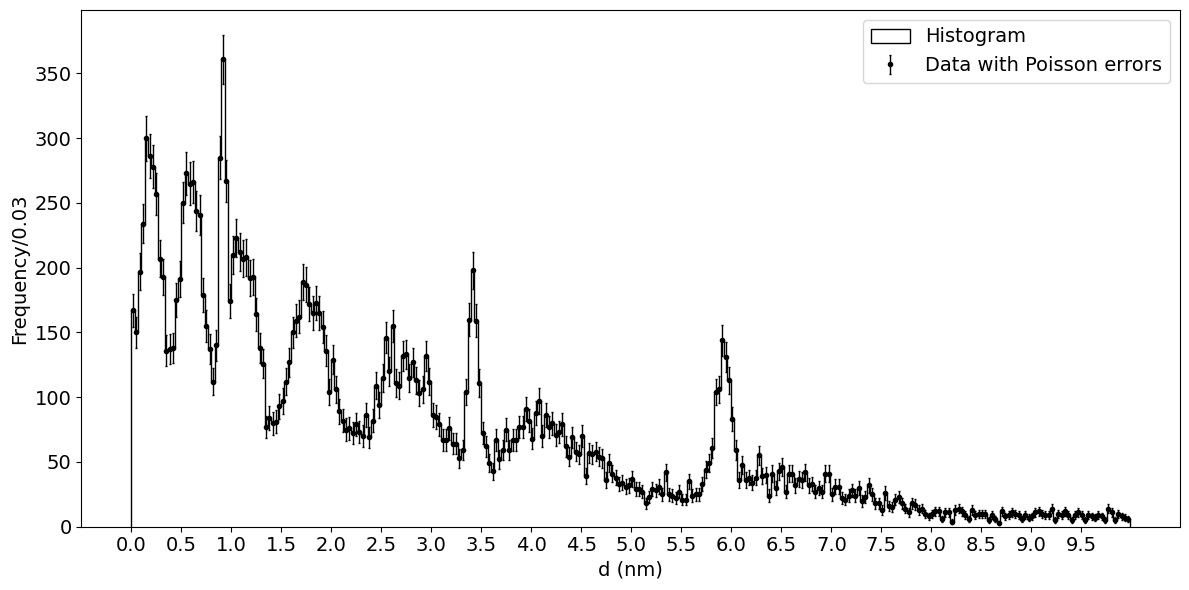

In [314]:
distBins = 300
distBinwidth = (max(distance)-0)/distBins

dist_counts, dist_binedges = np.histogram(distance, bins=distBins, range=(0,max(distance)))

x_dist = (dist_binedges[1:] + dist_binedges[:-1])/2
y_dist = dist_counts
y_dist_err = np.sqrt(dist_counts)

fig, ax = plt.subplots(figsize = (12,6))
ax.errorbar(x_dist, y_dist, yerr = y_dist_err, fmt='.k', ecolor='k', elinewidth=1, capsize=1, capthick=1, label = 'Data with Poisson errors')
ax.hist(distance, bins=distBins, range=(0,max(distance)), histtype='step', color='k', label='Histogram')
ax.set_xlabel('d (nm)', fontsize = 14)
ax.set_ylabel(f'Frequency/{distBinwidth:.2f}', fontsize = 14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xticks(np.arange(0, max(distance), 0.5))
ax.legend(fontsize = 14)
plt.tight_layout()
plt.show()

## 5.1.2
Assume the background is uniform

In [315]:
def dist_gauss(x, mu, sigma):
    return 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu)/sigma)**2)

def dist_exp(x, tau):
    """Exponential with lifetime tau"""
    return 1.0 / tau * np.exp(-x/tau)

def dist_fit_pdf(x, Ngauss, Nexp, mu, sigma, tau):
    return Nexp * distBinwidth * dist_exp(x, tau) + Ngauss * distBinwidth * gauss_pdf(x, mu, sigma)

In [316]:
d1, d2, d3 = 0.9, 3.4, 5.9
t1, t2, t3 = 50, -10, 50
left1, right1 = 0.08, 0.1
left2, right2 = 0.1, 0.1
left3, right3 = 0.1, 0.1


def single_gauss(x, y, sy, d, t, left, right):

    peak_mask = (x >= d - left) & (x <= d + right)
    Npeak = np.sum(y[peak_mask])

    mask = (x >= d - 2*left) & (x <= d + 2*right)

    Nback = np.sum(y[mask])- Npeak

    x_cut = x[mask]
    y_cut = y[mask]
    sy_cut = sy[mask]


    cfit = cost.LeastSquares(x_cut, y_cut, sy_cut, dist_fit_pdf)
    mfit = Minuit(cfit, Ngauss = Npeak, Nexp = Nback, mu=d, sigma=0.5, tau = t)
    mfit.migrad();

    vals = mfit.values[:]
    errors = mfit.errors[:]
    chi2 = mfit.fval
    Ndof = Npeak + Nback - len(vals)
    p = stats.chi2.sf(chi2, Ndof)

    params = np.array([chi2, Ndof, p])

    y_fit = dist_fit_pdf(x_cut, *vals)

    return vals, errors, params, y_fit, mask

gauss1_vals, gauss1_errs, gauss1_params, gauss1_fit, gauss1_mask = single_gauss(x_dist, y_dist, y_dist_err, d1, t1, left1, right1)
gauss2_vals, gauss2_errs, gauss2_params, gauss2_fit, gauss2_mask = single_gauss(x_dist, y_dist, y_dist_err, d2, t2, left2, right2)
gauss3_vals, gauss3_errs, gauss3_params, gauss3_fit, gauss3_mask = single_gauss(x_dist, y_dist, y_dist_err, d3, t3, left3, right3)

gauss1_x = x_dist[gauss1_mask]
gauss2_x = x_dist[gauss2_mask]
gauss3_x = x_dist[gauss3_mask]


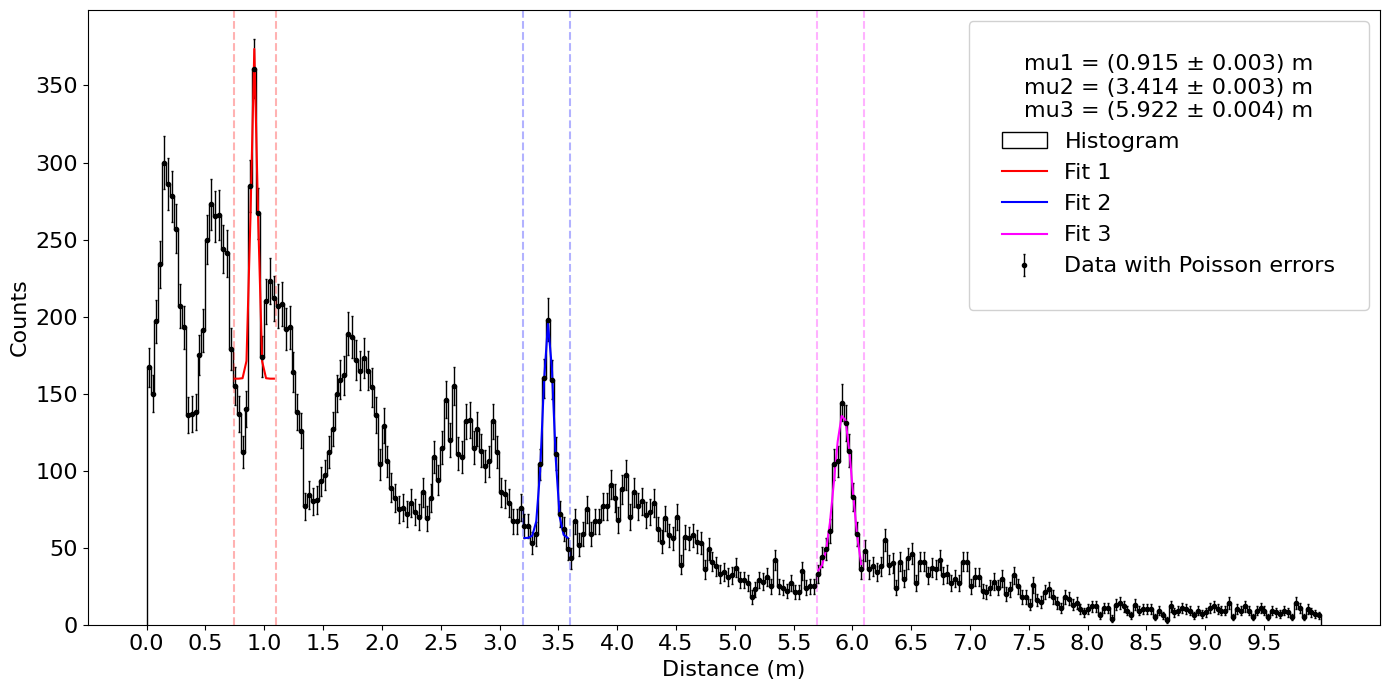

In [317]:
def threegauss_first_hist():
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.errorbar(x_dist, y_dist, yerr=y_dist_err, fmt='.k', ecolor='k', elinewidth=1, capsize=1, capthick=1, label='Data with Poisson errors')
    ax.hist(distance, bins=distBins, range=(0, max(distance)), histtype='step', color='k', label='Histogram')

    ax.plot(gauss1_x, gauss1_fit, color='red', label=f'Fit 1')
    plt.axvline(d1-2*left1, color='red', linestyle='dashed', alpha=0.3)
    plt.axvline(d1+2*right1, color='red', linestyle='dashed', alpha=0.3)

    ax.plot(gauss2_x, gauss2_fit, color='blue', label='Fit 2')
    plt.axvline(d2-2*left2, color='blue', linestyle='dashed', alpha=0.3)
    plt.axvline(d2+2*right2, color='blue', linestyle='dashed', alpha=0.3)

    ax.plot(gauss3_x, gauss3_fit, color='magenta', label='Fit 3')
    plt.axvline(d3-2*left3, color='magenta', linestyle='dashed', alpha=0.3)
    plt.axvline(d3+2*right3, color='magenta', linestyle='dashed', alpha=0.3)
    
    ax.set_xlabel('Distance (m)', fontsize=16)
    ax.set_ylabel('Counts', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_xticks(np.arange(0, max(distance), 0.5))

    fit_info = (
        f'mu1 = ({gauss1_vals[2]:.3f} ± {gauss1_errs[2]:.3f}) m\n'
        f'mu2 = ({gauss2_vals[2]:.3f} ± {gauss2_errs[2]:.3f}) m\n'
        f'mu3 = ({gauss3_vals[2]:.3f} ± {gauss3_errs[2]:.3f}) m'
    )

    legend = plt.legend(
        fontsize=16,
        title=fit_info,
        title_fontsize=16,
        loc='upper right',
        frameon=True,
        fancybox=True,
        framealpha=0.9,
        borderpad=1.5
    )
    legend.get_title().set_multialignment('left')

    plt.tight_layout()
    plt.show()
    return

threegauss_first_hist()

In [318]:
N_gauss1, N_gauss1_err = gauss1_vals[0], gauss1_errs[0]
N_gauss2, N_gauss2_err = gauss2_vals[0], gauss2_errs[0]
N_gauss3, N_gauss3_err = gauss3_vals[0], gauss3_errs[0]

N_w, N_w_err, chi2_Nw, p_Nw, Ndof_Nw = weighted_mean(np.array([N_gauss1, N_gauss2, N_gauss3]), np.array([N_gauss1_err, N_gauss2_err, N_gauss3_err]))

print(f'Weighted mean of N from three gaussians: {N_w:.2f} ± {N_w_err:.2f}, chi2 = {chi2_Nw:.2f}, p = {p_Nw:.2f}, Ndof = {Ndof_Nw}')



Weighted mean of N from three gaussians: 477.96 ± 25.94, chi2 = 4.36, p = 0.11, Ndof = 2


In [319]:
def single_gauss_2nd(data, N_bins,  label = None, ax = None):
    """
    This functions fits a Gaussian distribution to a histogram of the data.
    INPUT:
    data = 1D array of all the data points
    N_bins = number of bins
    label = label to put on x_axis
    ax = optional ax to plot on, if not stated will create a new figure
    """
    
    # Create a figure if needed
    if ax is None: fig, ax = plt.subplots(figsize = (12,6))

    # Extract values from histogram and outline data
    counts, bin_edges, _ = ax.hist(data, bins = N_bins, histtype='step', label = 'Histogram', color = 'k')
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    binwidth = bin_edges[1] - bin_edges[0]
    s_counts = np.sqrt(counts) # Poisson errors on the count in each bin
    
    # Removeing any bins without any counts in them:
    x = bin_center[counts > 0]
    y = counts[counts > 0]
    sy = s_counts[counts > 0]

    # Data with errorbars
    ax.errorbar(x, y, yerr = sy, fmt = '.k',  ecolor = 'k', elinewidth = 1, capsize = 1, capthick = 1, label = 'Data with Poisson errors')
    
    # Perform Gaussian fit with exponential background
    def func_gauss_exp_back(x, N, mu, sigma, k, tau):
        return N * binwidth * stats.norm.pdf(x, mu, sigma) + k * np.exp(-tau * x)

    # Minimizing chi2
    chi2_gauss = Chi2Regression(func_gauss_exp_back, x, y, sy)
    minuit_gauss = Minuit(chi2_gauss, N = len(data), mu = np.mean(data), sigma = np.std(data, ddof = 1), k = 1, tau = 1)  
    minuit_gauss.migrad(); 

    chi2_gauss = minuit_gauss.fval
    Ndof_gauss = len(x) - len(minuit_gauss.values)
    Prob_gauss = stats.chi2.sf(chi2_gauss, Ndof_gauss)
    
    # Extract values from fit
    mean = [minuit_gauss.values['mu'], minuit_gauss.errors['mu']]
    sigma = [minuit_gauss.values['sigma'], minuit_gauss.errors['sigma']]
    k = [minuit_gauss.values['k'], minuit_gauss.errors['k']]
    tau = [minuit_gauss.values['tau'], minuit_gauss.errors['tau']]
    N = [minuit_gauss.values['N'], minuit_gauss.errors['N']]

    # Plot
    xaxis = np.linspace(min(data), max(data), 100)
    y_gauss = func_gauss_exp_back(xaxis, *minuit_gauss.values)
    ax.plot(xaxis, y_gauss, linewidth = 1, color = 'red', label = 'Fit')
     
    d = {'N': N,
          'mu': mean,
          'sigma': sigma,
          'k': k,
          'tau': tau,
          'Ndof': Ndof_gauss,
          'Chi2': chi2_gauss,
          'p-val': Prob_gauss}

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 12, color = 'black')
    ax.text(0.02, 0.97, 'Gauss fit with exponential background', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top',                     color = 'black')

    ax.legend(fontsize = 14, loc = 'upper right')
    ax.set_xlabel(label, fontsize = 12)
    ax.set_ylabel(f'Frequency/{binwidth:.3f}', fontsize = 12)
    for name in minuit_gauss.parameters :
        value, error = minuit_gauss.values[name], minuit_gauss.errors[name]
        print(f"Fit value: {name} = {value:.5f} +/- {error:.5f}")
        
    Prob_value = stats.chi2.sf(chi2_gauss, Ndof_gauss) # The chi2 probability given ndof degrees of freedom
    print(f"Chi2 value: {chi2_gauss:.1f}")   
    print(f"Ndof = {Ndof_gauss:.0f}")
    print(f"Prob(Chi2,Ndof) = {Prob_value}")
    
    return N


Fit value: N = 510.69574 +/- 50.63059
Fit value: mu = 0.91016 +/- 0.00220
Fit value: sigma = 0.02635 +/- 0.00216
Fit value: k = 2.40542 +/- 1.58056
Fit value: tau = -2.05468 +/- 0.73276
Chi2 value: 60.3
Ndof = 45
Prob(Chi2,Ndof) = 0.0634279845444019


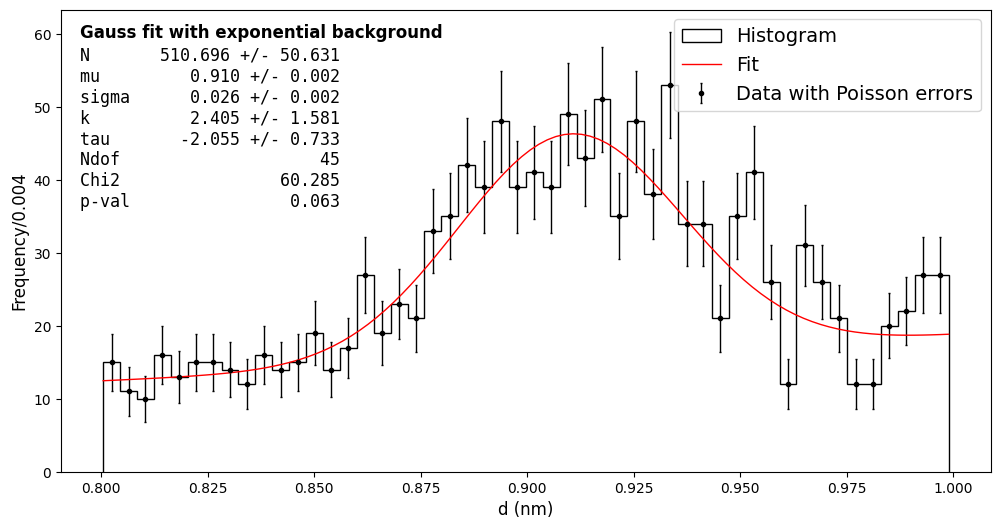

In [378]:
data_peak_1 = distance[(distance > 0.8) & (distance < 0.999)]

fig, ax = plt.subplots(figsize = (12,6))
N_peak1 = single_gauss_2nd(data_peak_1, N_bins = 50, label = 'd (nm)', ax = ax)
plt.show();

C:\Users\asker\AppData\Local\Temp\ipykernel_2292\3149351457.py:30: RuntimeWarning: overflow encountered in exp
  return N * binwidth * stats.norm.pdf(x, mu, sigma) + k * np.exp(-tau * x)


Fit value: N = 492.44747 +/- 37.69498
Fit value: mu = 3.41681 +/- 0.00309
Fit value: sigma = 0.04344 +/- 0.00305
Fit value: k = 169.35684 +/- 210.47266
Fit value: tau = 0.78073 +/- 0.37015
Chi2 value: 59.5
Ndof = 45
Prob(Chi2,Ndof) = 0.07215774444034281


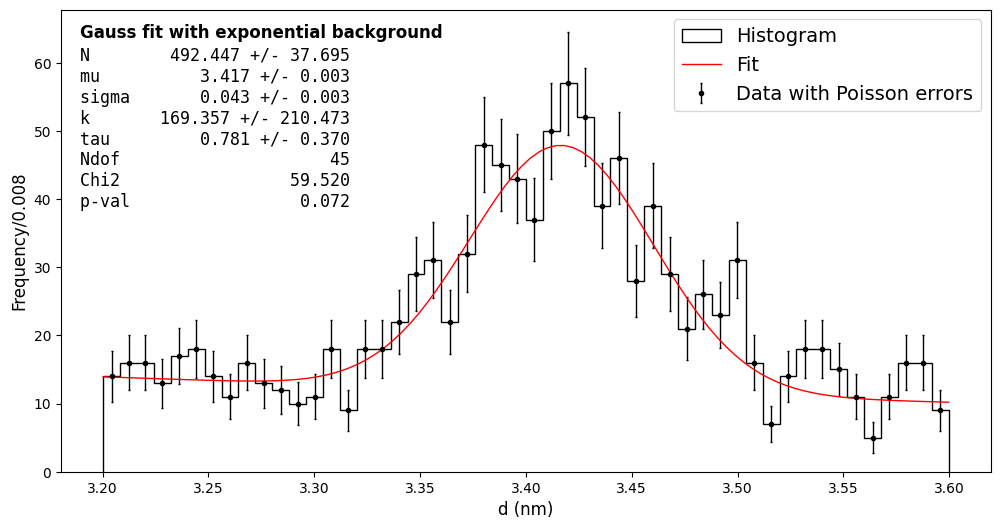

In [379]:
data_peak_2 = distance[(distance>3.2) & (distance<3.6)]
fig, ax = plt.subplots(figsize = (12,6))
N_peak2 = single_gauss_2nd(data_peak_2, N_bins = 50, label = 'd (nm)', ax = ax)
plt.show();

Fit value: N = 598.64909 +/- 71.90109
Fit value: mu = 5.91798 +/- 0.00472
Fit value: sigma = 0.07240 +/- 0.00669
Fit value: k = 35.40582 +/- 106.14446
Fit value: tau = 0.29492 +/- 0.51951
Chi2 value: 63.0
Ndof = 45
Prob(Chi2,Ndof) = 0.03895543633498454


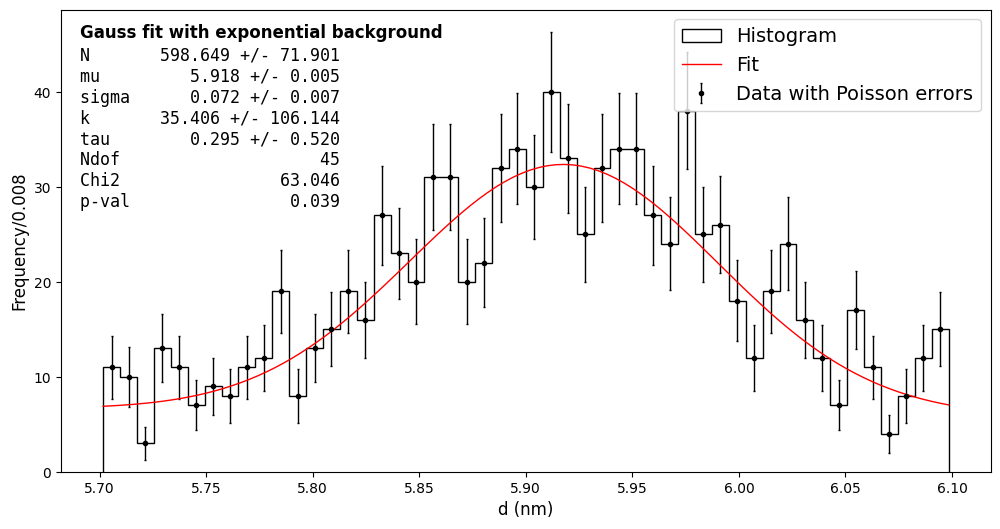

In [380]:
data_peak_3 = distance[(distance>5.7) & (distance<6.1)]

fig, ax = plt.subplots(figsize = (12,6))
N_peak3 = single_gauss_2nd(data_peak_3, N_bins = 50, label = 'd (nm)', ax = ax)
plt.show();

## 5.1.2

In [381]:
N_w_2nd, N_w_2nd_err, chi2_Nw_2nd, p_Nw_2nd, Ndof_Nw_2nd = weighted_mean(np.array([N_peak1[0], N_peak2[0], N_peak3[0]]), np.array([N_peak1[1], N_peak2[1], N_peak3[1]]))

print(f'Weighted mean of N from three gaussians (2nd method): {N_w_2nd:.2f} ± {N_w_2nd_err:.2f}, chi2 = {chi2_Nw_2nd:.2f}, p = {p_Nw_2nd:.2f}, Ndof = {Ndof_Nw_2nd}')


Weighted mean of N from three gaussians (2nd method): 513.94 ± 27.87, chi2 = 1.72, p = 0.42, Ndof = 2


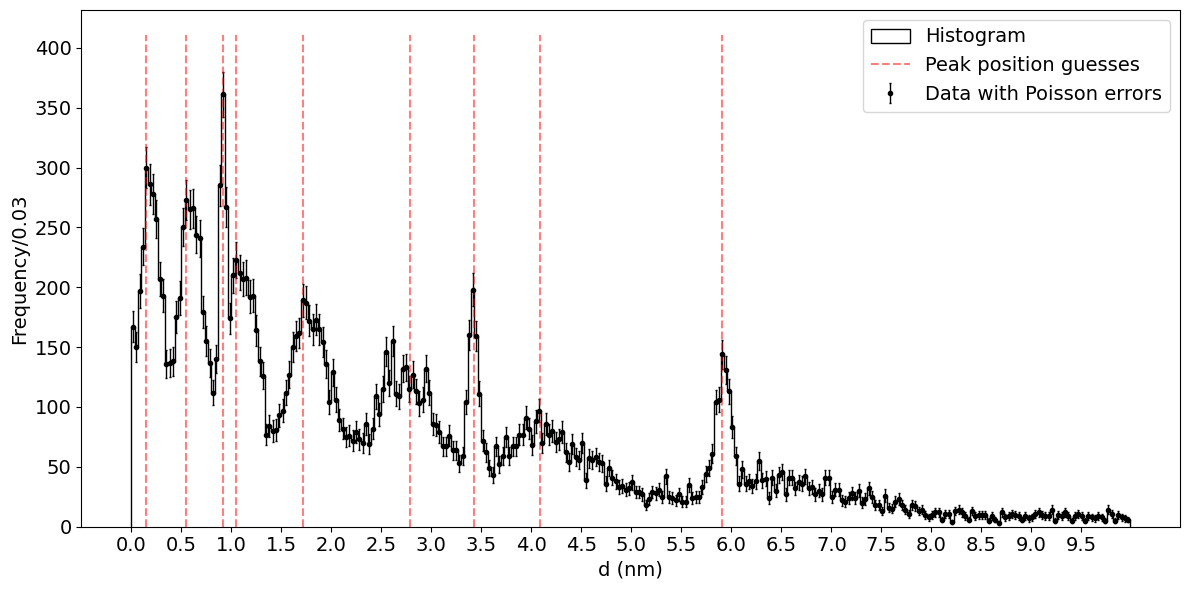

In [383]:
peak_positions_guesses = [0.15, 0.55, 0.92, 1.05, 1.72, 2.79, 3.43, 4.09, 5.91]

fig, ax = plt.subplots(figsize = (12,6))
ax.errorbar(x_dist, y_dist, yerr = y_dist_err, fmt='.k', ecolor='k', elinewidth=1, capsize=1, capthick=1, label = 'Data with Poisson errors')
ax.hist(distance, bins=distBins, range=(0,max(distance)), histtype='step', color='k', label='Histogram')
ax.vlines(peak_positions_guesses, ymin=0, ymax=max(y_dist)+50, colors='red', alpha = 0.5, linestyles='dashed', label='Peak position guesses')
ax.set_xlabel('d (nm)', fontsize = 14)
ax.set_ylabel(f'Frequency/{distBinwidth:.2f}', fontsize = 14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xticks(np.arange(0, max(distance), 0.5))
ax.legend(fontsize = 14)
plt.tight_layout()
plt.show()


In [388]:

N_peaks = len(peak_positions_guesses)

def multi_gauss_exp_back(x, *params):
    """Model function: sum of multiple Gaussians + exponential background.
    params: [N1, mu1, sigma1, N2, mu2, sigma2, ..., a, lambd]
    """
    n_peaks = (len(params) - 2) // 3
    a = params[-2]
    lambd = params[-1]
    
    y = a * np.exp(-lambd * x)
    
    for i in range(n_peaks):
        N = params[3*i]
        mu = params[3*i + 1]
        sigma = params[3*i + 2]
        y += N * stats.norm.pdf(x, mu, sigma)
    
    return y

def hist_with_multiple_gauss(data, N_bins, peak_positions, label = None, ax = None):
    """
    This functions fits a Gaussian distribution to a histogram of the data.
    INPUT:
    data = 1D array of all the data points
    N_bins = number of bins
    label = label to put on x_axis
    ax = optional ax to plot on, if not stated will create a new figure
    """
    
    # Create a figure if needed
    if ax is None: fig, ax = plt.subplots(figsize = (12,6))

    # Extract values from histogram and outline data
    counts, bin_edges, _ = ax.hist(data, bins = N_bins, histtype = 'step', label = 'Histogram', color = 'k')
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    binwidth = bin_edges[1] - bin_edges[0]
    s_counts = np.sqrt(counts) # Poisson errors on the count in each bin
    
    # Removeing any bins without any counts in them:
    x = bin_center[counts > 0]
    y = counts[counts > 0]
    sy = s_counts[counts > 0]

    params = []
    for pos in peak_positions:
        N_guess = max(y)
        mu_guess = pos
        sigma_guess = 0.1
        params += [N_guess, mu_guess, sigma_guess]
    params += [1, 1]  # Initial guesses for a and lambd

    print(params)

    # Data with errorbars
    ax.errorbar(x, y, yerr = sy, fmt = '.k',  ecolor = 'k', elinewidth = 1, capsize = 1, capthick = 1, label = 'Data with Poisson errors')
    
    # Perform Gaussian fit with exponential background
    def multi_gauss_exp_back(x, *params):
        """Model function: sum of multiple Gaussians + exponential background.
        params: [N1, mu1, sigma1, N2, mu2, sigma2, ..., a, lambd]
        """
        n_peaks = (len(params) - 2) // 3
        a = params[-2]
        lambd = params[-1]
        
        y = a * np.exp(-lambd * x)
        
        for i in range(n_peaks):
            N = params[3*i]
            mu = params[3*i + 1]
            sigma = params[3*i + 2]
            y += binwidth * N * stats.norm.pdf(x, mu, sigma)
        
        return y

    # Minimizing chi2
    chi2_gauss = Chi2Regression(multi_gauss_exp_back, x, y, sy)
    minuit_gauss = Minuit(chi2_gauss, *params)  
    minuit_gauss.migrad(); 

    chi2_gauss = minuit_gauss.fval
    Ndof_gauss = len(x) - len(minuit_gauss.values)
    Prob_gauss = stats.chi2.sf(chi2_gauss, Ndof_gauss)

    # Plot
    xaxis = np.linspace(min(data), max(data), 100)
    y_gauss = multi_gauss_exp_back(xaxis, *minuit_gauss.values)
    ax.plot(xaxis, y_gauss, linewidth = 1, color = 'red', label = 'Fit')
     
    d = {'Chi2': chi2_gauss,
            'Ndof': Ndof_gauss,
          'p-val': Prob_gauss}

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 14, color = 'black')
    ax.text(0.02, 0.97, 'Gauss fit with exponential background', weight = 'heavy', fontsize = 14, transform = ax.transAxes, verticalalignment = 'top',                     color = 'black')

    ax.legend(fontsize = 14)
    ax.set_xlabel(label, fontsize=14)
    ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=14)
    ax.set_xticks(np.arange(0, max(distance), 0.5))
    ax.set_ylim(0, max(y)*1.5)
    for name in minuit_gauss.parameters :
        value, error = minuit_gauss.values[name], minuit_gauss.errors[name]
        print(f"Fit value: {name} = {value:.5f} +/- {error:.5f}")
        
    Prob_value = stats.chi2.sf(chi2_gauss, Ndof_gauss) # The chi2 probability given ndof degrees of freedom
    print(f"Chi2 value: {chi2_gauss:.1f}")   
    print(f"Ndof = {Ndof_gauss:.0f}")
    print(f"Prob(Chi2,Ndof) = {Prob_value}")
    
    return 

[np.float64(361.0), 0.15, 0.1, np.float64(361.0), 0.55, 0.1, np.float64(361.0), 0.92, 0.1, np.float64(361.0), 1.05, 0.1, np.float64(361.0), 1.72, 0.1, np.float64(361.0), 2.79, 0.1, np.float64(361.0), 3.43, 0.1, np.float64(361.0), 4.09, 0.1, np.float64(361.0), 5.91, 0.1, 1, 1]
Fit value: x0 = 3990.99323 +/- 668.17518
Fit value: x1 = 0.18712 +/- 0.00434
Fit value: x2 = 0.15369 +/- 0.01187
Fit value: x3 = 2386.77678 +/- 174.25906
Fit value: x4 = 0.57493 +/- 0.00483
Fit value: x5 = 0.10370 +/- 0.00437
Fit value: x6 = 6849.44988 +/- 1172.35918
Fit value: x7 = 1.03162 +/- 0.00745
Fit value: x8 = 0.24671 +/- 0.01425
Fit value: x9 = -13956.14916 +/- 5688.73494
Fit value: x10 = 1.61562 +/- 0.06016
Fit value: x11 = 1.14623 +/- 0.14969
Fit value: x12 = 5518.41891 +/- 644.17744
Fit value: x13 = 1.74823 +/- 0.00873
Fit value: x14 = 0.25050 +/- 0.00931
Fit value: x15 = 7571.94068 +/- 1560.31842
Fit value: x16 = 2.61175 +/- 0.01792
Fit value: x17 = 0.44766 +/- 0.02626
Fit value: x18 = 530.81228 +/- 3

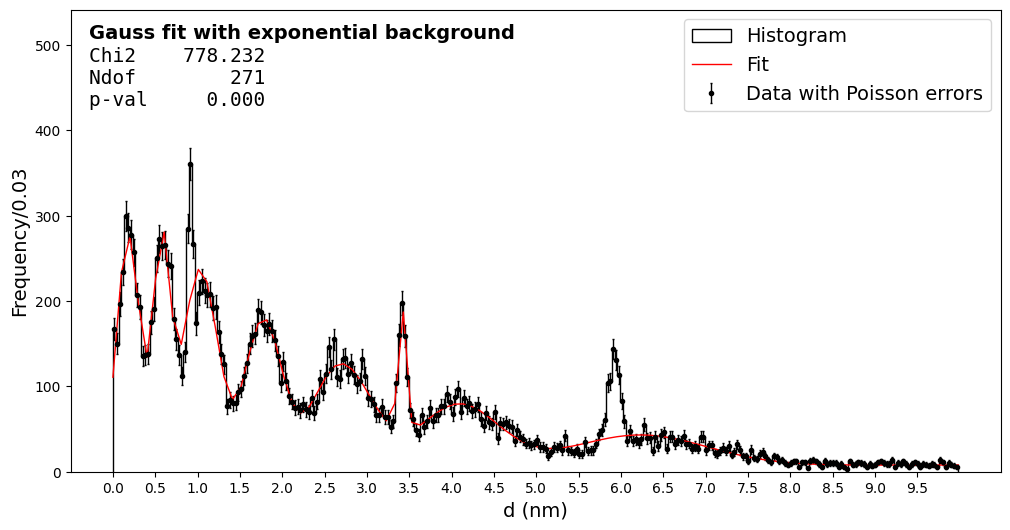

In [389]:
# Plotting histogram with multiple Gaussian fit
fig, ax = plt.subplots(figsize = (12,6))
hist_with_multiple_gauss(distance, N_bins = 300, peak_positions = peak_positions_guesses, label = 'd (nm)', ax = ax)
#plt.title('Histogram with Multiple Gaussian fit')
plt.show();

## 5.2
### 5.2.1

In [396]:
align_year = np.array([-2600, -2583, -2572, -2554, -2522, -2489, -2446, -2433])

align_east = np.array([-20.6, -17.3, -8.7, -3.4, 6.0, 12.4, 23, 30])
align_east_err = np.array([1.0, 0.2, 0.2, 0.2, 0.2, 1.0, 10, 10])

align_west = np.array([-18.1, -11.8, 0, -2.8, 6.0, 14.1, 0, 0])
align_west_err = np.array([1.0, 0.2, 0, 0.2, 0.2, 1.8, 0, 0])

def z_test_align(mu1, sig1, mu2, sig2):
    z = (mu1 - mu2) / np.sqrt(sig1**2 + sig2**2)
    p = 2 * (1 - norm.cdf(abs(z)))  # two-sided p-value
    return z, p

for E, W, Ey, Wy in zip(align_east, align_west, align_east_err, align_west_err):
    z, p = z_test_align(E, Ey, W, Wy)
    print(f'Alignment East: {E} ± {Ey}, West: {W} ± {Wy} => z = {z}, p-value = {p:.9f}')



Alignment East: -20.6 ± 1.0, West: -18.1 ± 1.0 => z = -1.7677669529663687, p-value = 0.077099872
Alignment East: -17.3 ± 0.2, West: -11.8 ± 0.2 => z = -19.445436482630054, p-value = 0.000000000
Alignment East: -8.7 ± 0.2, West: 0.0 ± 0.0 => z = -43.49999999999999, p-value = 0.000000000
Alignment East: -3.4 ± 0.2, West: -2.8 ± 0.2 => z = -2.1213203435596424, p-value = 0.033894854
Alignment East: 6.0 ± 0.2, West: 6.0 ± 0.2 => z = 0.0, p-value = 1.000000000
Alignment East: 12.4 ± 1.0, West: 14.1 ± 1.8 => z = -0.8255929830036742, p-value = 0.409035017
Alignment East: 23.0 ± 10.0, West: 0.0 ± 0.0 => z = 2.3, p-value = 0.021448220
Alignment East: 30.0 ± 10.0, West: 0.0 ± 0.0 => z = 3.0, p-value = 0.002699796


In [414]:
def EW_combine(E, E_err, W, W_err):
    val, val_err, chi2, prob, exp = weighted_mean(np.array([E,W]), np.array([E_err, W_err]))
    return val, val_err, prob

In [422]:
def EW_agree(E, E_err, W, W_err):
    final_vals = np.array([])
    final_errs = np.array([])
    z_vals = np.array([])
    systematic_errors = np.zeros_like(E)
    p_vals = np.zeros_like(E)

    for i in range(len(E)):
        if E_err[i] == 0 or W_err[i] == 0:
            final_vals = np.concatenate((final_vals, np.array([E[i]])))
            final_errs = np.concatenate((final_errs, np.array([E_err[i]])))
            z_vals = np.concatenate((z_vals, np.array([0])))
            systematic_errors[i] = 0
            continue
        z = (E[i] - W[i]) / np.sqrt(E_err[i]**2 + W_err[i]**2)
        if np.abs(z) <= 2: 
            combined_val, combined_err, prob = EW_combine(E[i], E_err[i], W[i], W_err[i])
            p_vals[i] = prob
            final_vals = np.concatenate((final_vals, np.array([combined_val])))
            final_errs = np.concatenate((final_errs, np.array([combined_err])))
            z_vals = np.concatenate((z_vals, np.array([z])))
            systematic_errors[i] = 0
        else:
            systm_err = 1e-2
            finish_adj = False
            while finish_adj == False:
                adj_E_err = np.sqrt(E_err[i]**2 + systm_err**2)
                adj_W_err = np.sqrt(W_err[i]**2 + systm_err**2)
                z_adj = (E[i] - W[i]) / np.sqrt(adj_E_err**2 + adj_W_err**2)
                if np.abs(z_adj) <= 2:
                    combined_val, combined_err, prob = EW_combine(E[i], adj_E_err, W[i], adj_W_err)
                    p_vals[i] = prob
                    final_vals = np.concatenate((final_vals, np.array([combined_val])))
                    final_errs = np.concatenate((final_errs, np.array([combined_err])))
                    z_vals = np.concatenate((z_vals, np.array([z_adj])))
                    systematic_errors[i] = systm_err
                    finish_adj = True
                else:
                    systm_err += 1e-2
    
    return final_vals, final_errs, z_vals, systematic_errors, p_vals

fin_align_vals, fin_align_errs, fin_align_z, fin_sysm_err, fin_p_vals = EW_agree(align_east, align_east_err, align_west, align_west_err)
print(f'combined values: {fin_align_vals}')
print(f'combined errors: {fin_align_errs}')
print(f'z-values: {fin_align_z}')
print(f'systematic errors added: {fin_sysm_err}')


print(f'p_values of combined alignments: {fin_p_vals}')


combined values: [-19.35      -14.55       -8.7        -3.1         6.         12.8009434
  23.         30.       ]
combined errors: [ 0.70710678  1.37905765  0.2         0.15231546  0.14142136  0.87415728
 10.         10.        ]
z-values: [-1.76776695 -1.99411533  0.         -1.96959649  0.         -0.82559298
  0.          0.        ]
systematic errors added: [0.   1.94 0.   0.08 0.   0.   0.   0.  ]
p_values of combined alignments: [0.07709987 0.04613945 0.         0.04888463 1.         0.40903502
 0.         0.        ]


### 5.2.2

def EW_ensure_agree(E, E_err, W, W_err, z):
    align = np.array([])
    align_err = np.array([])

    for i in range(len(z)):
        if z[i]<2:
            val, val_err = EW_combine(E[i], E_err[i], W[i], W_err[i])
            align = np.concatenate((align, np.array([val])))
            align_err =  np.concatenate((align_err, np.array([val_err])))
        else: 
            val, val_err = EW_combine(E[i], E_err[i], W[i], W_err[i])
            syst_err = np.abs(E[i]-W[i])/2
            total_err = np.sqrt(val_err**2 + syst_err**2)
            align = np.concatenate((align, np.array([val])))
            align_err =  np.concatenate((align_err, np.array([total_err])))
        
    return align, align_err

final_align, final_align_err = EW_ensure_agree(E_filt, E_err_filt, W_filt, W_err_filt, z_align)


## 5.2.3

In [418]:
def lin_fit(x, a, b):
    return a*x + b

def pyramid_align_fit(x, y, sy):
    cfit = cost.LeastSquares(x, y, sy, lin_fit)
    mfit = Minuit(cfit, a=-50, b=20)  
    mfit.migrad();
    vals = mfit.values[:]
    errs = mfit.errors[:]
    chi2 = mfit.fval
    Ndof = len(x) - len(vals)
    p = stats.chi2.sf(chi2, Ndof)
    return  vals, errs, chi2, p, Ndof

pyramid_fit = pyramid_align_fit(align_year, fin_align_vals, fin_align_errs)

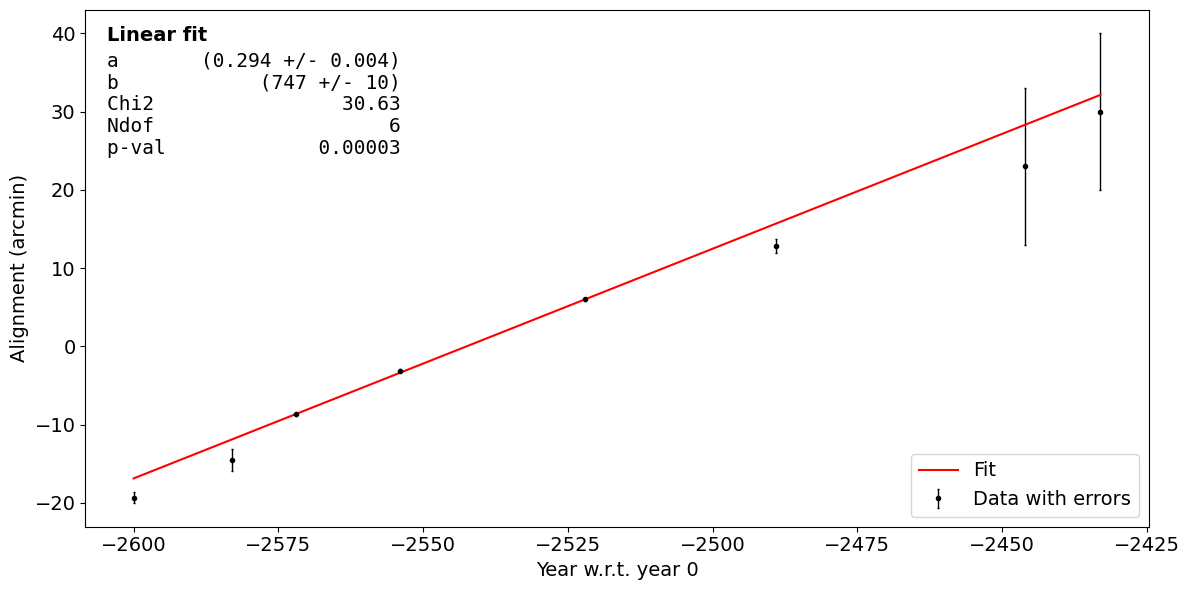

In [432]:
def pyramid_fitplot(x, y, sy):
    vals, errs, chi2, p, Ndof = pyramid_fit

    x_fit = np.linspace(min(x), max(x), 1000)
    y_fit = lin_fit(x_fit, vals[0], vals[1])

    fig, ax = plt.subplots(figsize=(12,6))
    ax.errorbar(x, y, yerr=sy,  label='Data with errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1)
    ax.plot(x_fit, y_fit, '-', color='red', label='Fit')
    ax.set_xlabel('Year w.r.t. year 0', fontsize=14)
    ax.set_ylabel('Alignment (arcmin)', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)

    d = {
        'a': f"({vals[0]:.3f} +/- {errs[0]:.3f})",
        'b': f"({vals[1]:.0f} +/- {errs[1]:.0f})",
        'Chi2': f"{chi2:.2f}",
        'Ndof': Ndof,
        'p-val': f"{p:.5f}",
    }

    text = nice_string_output(d, extra_spacing = 3, decimals = 5)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 14, color = 'black')
    ax.text(0.02, 0.97, 'Linear fit', weight = 'heavy', fontsize = 14, transform = ax.transAxes, verticalalignment = 'top',                     color = 'black')

    ax.legend(fontsize = 14)
    plt.tight_layout()
    plt.show()
    return

pyramid_fitplot(align_year, fin_align_vals, fin_align_errs)

In [ ]:
real_shift = 0.274 
est_shift = pyramid_fit[0][0]
est_shift_err = pyramid_fit[1][0]

print(est_shift, est_shift_err)
z_pyr, p_pyr = z_test_align(est_shift, est_shift_err, real_shift, 0)

print(f'Estimated shift: {est_shift:.3f} ± {est_shift_err:.3f} arcmin/year')
print(f'Z-score of estimated shift vs real shift: {z_pyr:.2f} with p-value: {p_pyr:.7f}')

pyramid_vals = pyramid_fit[0]
pyramid_errs = pyramid_fit[1]
print(pyramid_vals)


0.2936218069376899 0.004106723770361076
Estimated shift: 0.294 ± 0.004 arcmin/year
Z-score of estimated shift vs real shift: 4.78 with p-value: 0.0000018
[0.2936218069376899, 746.5317787310923]


## 5.2.5

In [444]:
trueN = 2467
khufu, khufu_err = fin_align_vals[3], fin_align_errs[3]
print(khufu, khufu_err)

print(khufu-pyramid_vals[1]/pyramid_vals[0])
def khufu_err():
    a, b = pyramid_vals
    a_err, b_err = pyramid_errs

    dh_da = -b / a**2
    dh_db = 1 / a

    khufu_err = np.sqrt( (dh_da * a_err)**2 + (dh_db * b_err)**2 )
    print(khufu_err)
    return 

khufu_err()

-3.1 0.1523154621172782
-2545.5943280507613
50.31315938035091


align = shift*year + y0

year = align-y0/shift

